/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/Captured_Images/Samsung_phone/Images/M_Img_Android_D29_L2_r35_a-10_b5_Ob2.jpg


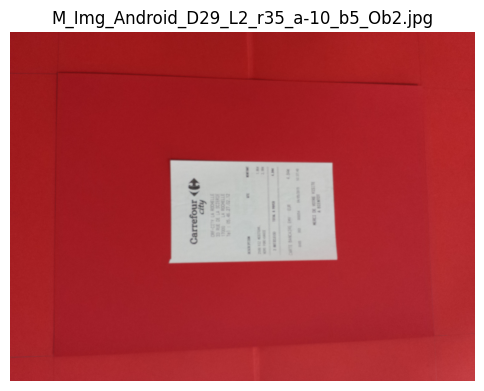

In [35]:
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

# Pick random image path
sample_path = random.choice(df['image_path'].tolist())

# Extract filename only
filename = os.path.basename(sample_path)

# Open image
img = Image.open(sample_path)
print(sample_path)
# Display
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(filename)
plt.show()


# PREPROCESSING

In [1]:
# =========================================================
# IMPORTS + CLEAN OUTPUT
# =========================================================
import os
import shutil
import cv2

WORKING_DIR = "/kaggle/working/Final_Images_CROPPED"

# remove old cropped data
if os.path.exists(WORKING_DIR):
    shutil.rmtree(WORKING_DIR)

os.makedirs(WORKING_DIR, exist_ok=True)
print("🧹 Old cropped dataset removed")


# =========================================================
# CENTER CROP
# =========================================================
def center_crop(img, crop_w, crop_h):
    h, w = img.shape[:2]
    crop_w = min(crop_w, w)
    crop_h = min(crop_h, h)
    x1 = (w - crop_w) // 2
    y1 = (h - crop_h) // 2
    return img[y1:y1+crop_h, x1:x1+crop_w]


# =========================================================
# CROP FUNCTIONS
# =========================================================
def crop_group_1_nokia(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 2600, 1850))

def crop_group_1_samsung(src, dst):
    img = cv2.imread(src)
    h, w = img.shape[:2]
    crop_w = int(0.85 * w)
    crop_h = int(0.85 * h)
    cv2.imwrite(dst, center_crop(img, crop_w, crop_h))

def crop_group_2_nokia(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 1600, 850))

def crop_group_2_samsung(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 2130, 1270))

def crop_group_3_nokia(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 950, 700))

def crop_group_3_samsung(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 1200, 860))

def crop_group_4_nokia(src, dst):
    img = cv2.imread(src)
    cv2.imwrite(dst, center_crop(img, 2130, 1270))


# =========================================================
# GROUP RANGES
# =========================================================
NOKIA_GROUP_RANGES = {
    "group1": [(0,1199), (1500,1619), (1800,2019), (2075,2096)],
    "group2": [(1200,1379), (2020,2052)],
    "group3": [(1380,1499), (2053,2074)],
    "group4": [(1620,1799), (2097,2129)]
}

SAMSUNG_GROUP_RANGES = {
    "group1_samsung": [(0,1199), (1800,2019)],
    "group1_nokia_crop": [(1500,1619), (2075,2096)],
    "group2": [(1200,1379), (1620,1799), (2020,2052), (2097,2129)],
    "group3": [(1380,1499), (2053,2074)]
}


# =========================================================
# PROCESS FUNCTION (SAVE INTO Images/)
# =========================================================
def process_phone_folder(input_dir, output_dir, phone_type):
    images_out = os.path.join(output_dir, "Images")
    os.makedirs(images_out, exist_ok=True)

    images = sorted([
        f for f in os.listdir(input_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    ranges = NOKIA_GROUP_RANGES if phone_type == "nokia" else SAMSUNG_GROUP_RANGES

    for group, intervals in ranges.items():
        for start, end in intervals:
            for img_name in images[start:end+1]:
                src = os.path.join(input_dir, img_name)
                dst = os.path.join(images_out, img_name)

                if phone_type == "nokia":
                    if group == "group1":
                        crop_group_1_nokia(src, dst)
                    elif group == "group2":
                        crop_group_2_nokia(src, dst)
                    elif group == "group3":
                        crop_group_3_nokia(src, dst)
                    elif group == "group4":
                        crop_group_4_nokia(src, dst)

                elif phone_type == "samsung":
                    if group == "group1_samsung":
                        crop_group_1_samsung(src, dst)
                    elif group == "group1_nokia_crop":
                        crop_group_1_nokia(src, dst)
                    elif group == "group2":
                        crop_group_2_samsung(src, dst)
                    elif group == "group3":
                        crop_group_3_samsung(src, dst)


# =========================================================
# RUN CROPPING
# =========================================================
BASE_INPUT = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/Captured_Images"

process_phone_folder(
    os.path.join(BASE_INPUT, "Nokia_phone", "Images"),
    os.path.join(WORKING_DIR, "Nokia_phone"),
    "nokia"
)

process_phone_folder(
    os.path.join(BASE_INPUT, "Samsung_phone", "Images"),
    os.path.join(WORKING_DIR, "Samsung_phone"),
    "samsung"
)

print("✅ Cropping finished successfully")
print("📁 Output at:", WORKING_DIR)


🧹 Old cropped dataset removed
✅ Cropping finished successfully
📁 Output at: /kaggle/working/Final_Images_CROPPED


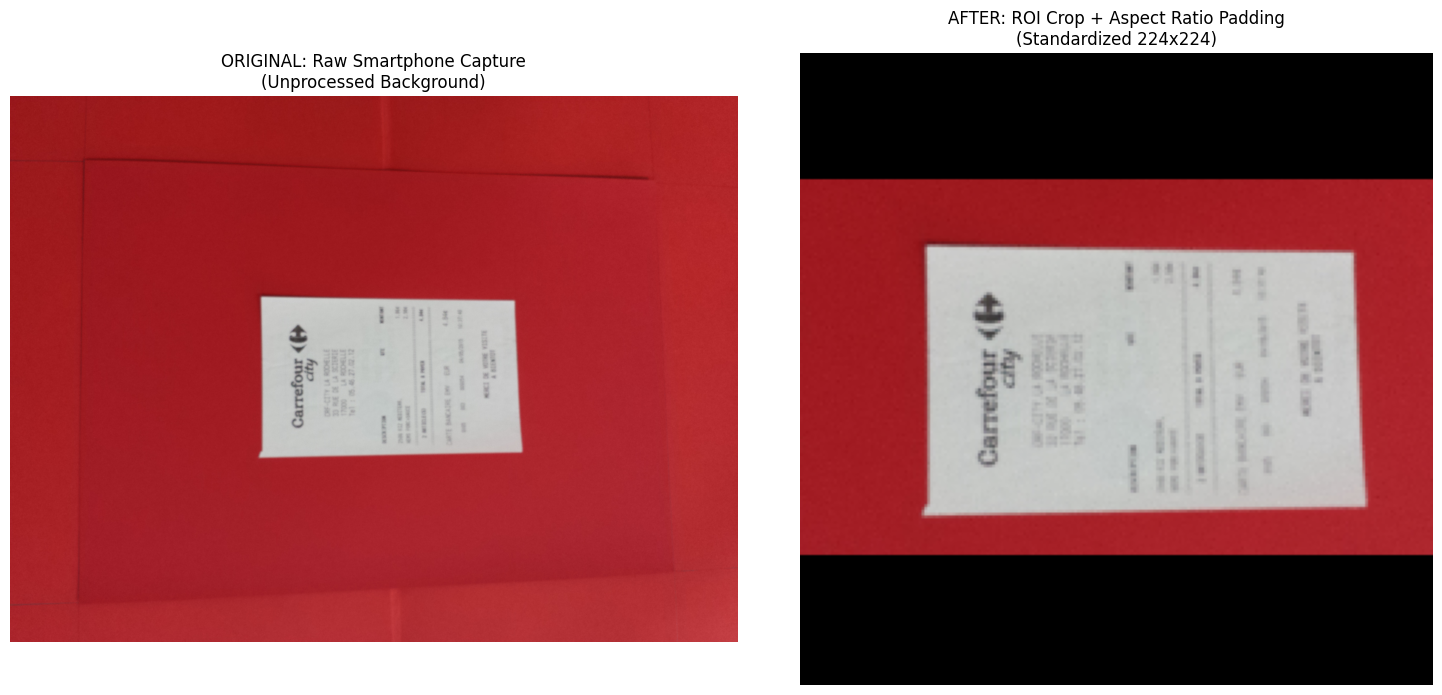

In [36]:
import matplotlib.pyplot as plt
import cv2
import os

# 1. Define your path to a processed image (adjust filename as needed)
# Since your code saves to /Images/ within the phone folders:
SAMPLE_IMAGE_PATH = "/kaggle/working/Final_Images_CROPPED/Samsung_phone/Images/M_Img_Android_D29_L2_r35_a-10_b5_Ob2.jpg"

# 2. Get the Original Raw Image for "Before" (from your Input directory)
RAW_IMAGE_PATH = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/Captured_Images/Samsung_phone/Images/M_Img_Android_D29_L2_r35_a-10_b5_Ob2.jpg"

# 3. Process the "After" image with your Padding logic
def apply_resize(image_path):
    img = cv2.imread(image_path)
    # Applying your specific resize with padding function
    target_size = 224
    h, w, _ = img.shape
    scale = target_size / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    image_resized = cv2.resize(img, (new_w, new_h))
    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left
    return cv2.copyMakeBorder(image_resized, pad_top, pad_bottom, pad_left, pad_right, 
                              cv2.BORDER_CONSTANT, value=[0, 0, 0])

# Load and Convert for Plotting
before_img = cv2.cvtColor(cv2.imread(RAW_IMAGE_PATH), cv2.COLOR_BGR2RGB)
after_img = cv2.cvtColor(apply_resize(SAMPLE_IMAGE_PATH), cv2.COLOR_BGR2RGB)

# 4. Final Output Display
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(before_img)
plt.title(f"ORIGINAL: Raw Smartphone Capture\n(Unprocessed Background)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(after_img)
plt.title(f"AFTER: ROI Crop + Aspect Ratio Padding\n(Standardized 224x224)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

# Load CSVs
train_df = pd.read_csv("/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv")
test_df = pd.read_csv("/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv")

# Add split column
train_df['split'] = 'train'
test_df['split'] = 'test'

# Combine for global EDA
df = pd.concat([train_df, test_df], ignore_index=True)

# Define labels and numeric features
label_cols = ['blur_motion', 'blur_outfocus', 'document_skew', 'lighting_shadow']

numeric_features = [
    'var_laplacian',
    'tenengrad',
    'brenner',
    'fft_highfreq_ratio',
    'directional_grad_ratio',
    'skew_hough_angle'
]

# Ensure labels are integers
df[label_cols] = df[label_cols].astype(int)

print("Dataset Shape:", df.shape)


Dataset Shape: (4260, 12)


# EDA

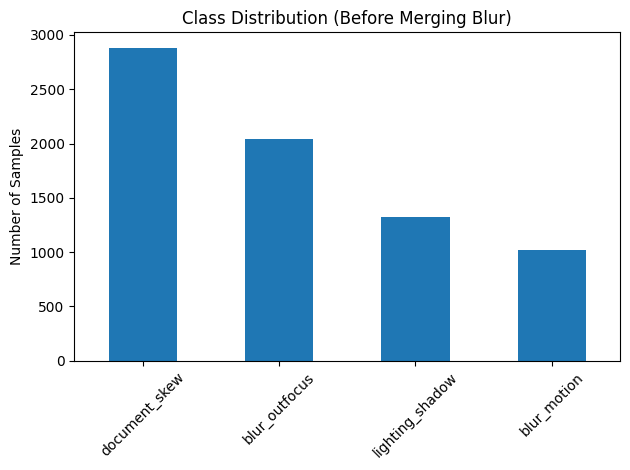

document_skew      2880
blur_outfocus      2040
lighting_shadow    1320
blur_motion        1020
dtype: int64


In [12]:
plt.figure()
label_counts = df[label_cols].sum().sort_values(ascending=False)

label_counts.plot(kind='bar')
plt.title("Class Distribution (Before Merging Blur)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(label_counts)


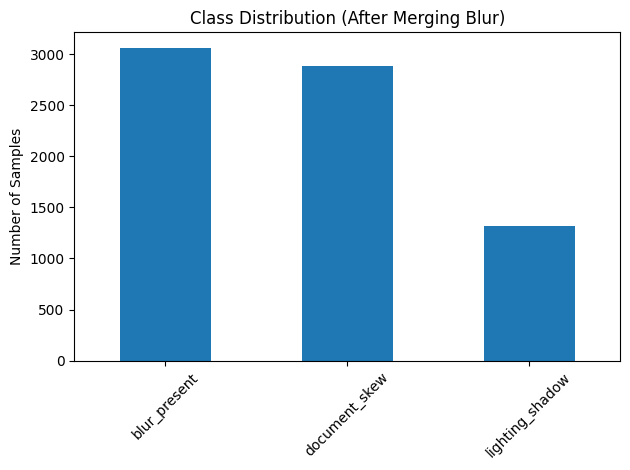

blur_present       3060
document_skew      2880
lighting_shadow    1320
dtype: int64


In [13]:
df['blur_present'] = ((df['blur_motion'] == 1) | 
                      (df['blur_outfocus'] == 1)).astype(int)

merged_labels = ['blur_present', 'document_skew', 'lighting_shadow']

plt.figure()
merged_counts = df[merged_labels].sum().sort_values(ascending=False)

merged_counts.plot(kind='bar')
plt.title("Class Distribution (After Merging Blur)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(merged_counts)


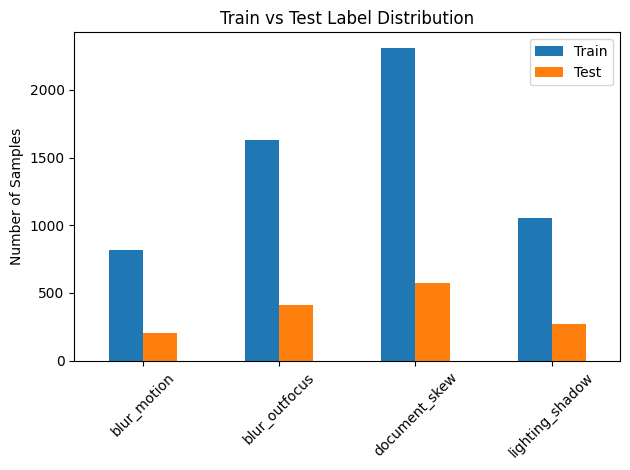

                 Train  Test
blur_motion        819   201
blur_outfocus     1628   412
document_skew     2309   571
lighting_shadow   1051   269


In [14]:
train_counts = train_df[label_cols].sum()
test_counts = test_df[label_cols].sum()

dist_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

dist_df.plot(kind='bar')
plt.title("Train vs Test Label Distribution")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(dist_df)


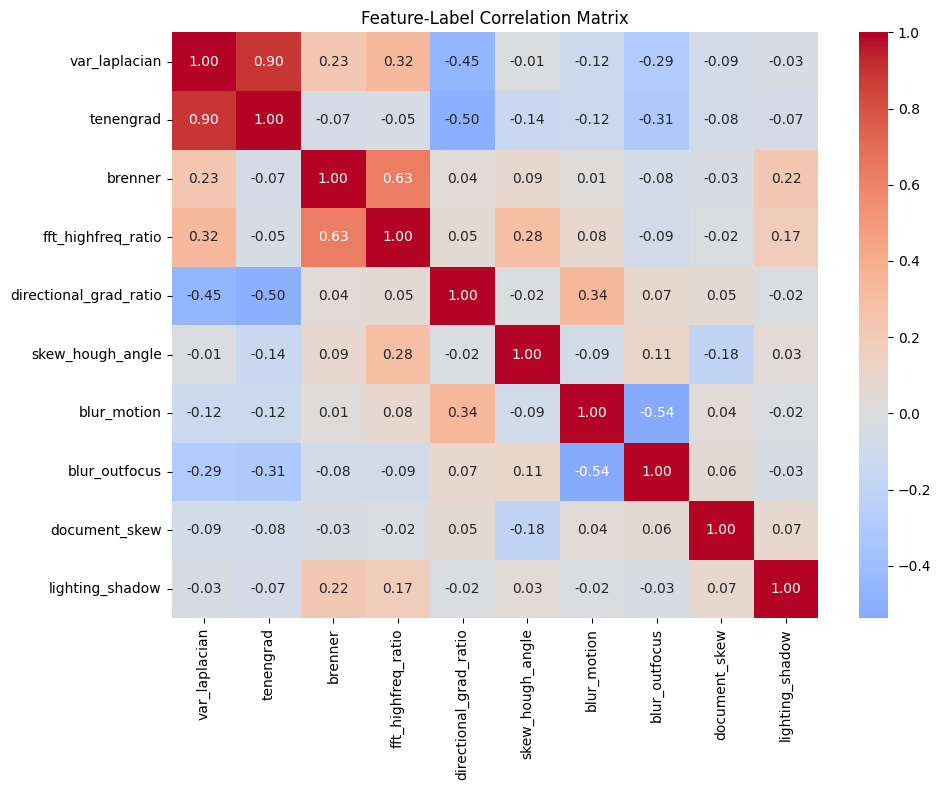

In [15]:
analysis_cols = numeric_features + label_cols

corr_matrix = df[analysis_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature-Label Correlation Matrix")
plt.tight_layout()
plt.show()


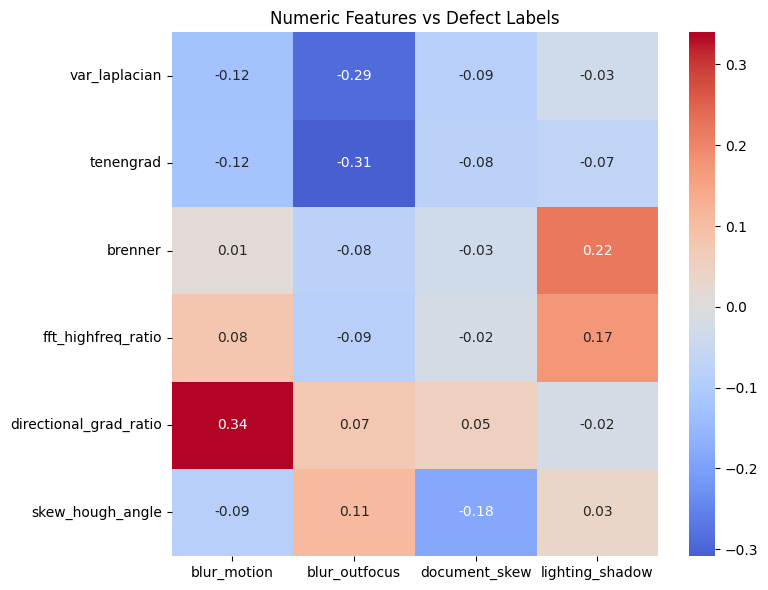

                        blur_motion  blur_outfocus  document_skew  \
var_laplacian             -0.123759      -0.290606      -0.086218   
tenengrad                 -0.123183      -0.308424      -0.077362   
brenner                    0.010649      -0.077221      -0.033425   
fft_highfreq_ratio         0.080200      -0.087376      -0.017456   
directional_grad_ratio     0.339615       0.074107       0.051595   
skew_hough_angle          -0.086667       0.107852      -0.184208   

                        lighting_shadow  
var_laplacian                 -0.034296  
tenengrad                     -0.066627  
brenner                        0.222487  
fft_highfreq_ratio             0.173100  
directional_grad_ratio        -0.018104  
skew_hough_angle               0.033666  


In [16]:
feature_label_corr = corr_matrix.loc[numeric_features, label_cols]

plt.figure(figsize=(8,6))
sns.heatmap(feature_label_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Features vs Defect Labels")
plt.tight_layout()
plt.show()

print(feature_label_corr)


In [19]:
import os

BASE_PATH = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/Captured_Images"

df['image_path'] = df['image_path'].apply(
    lambda x: os.path.join(BASE_PATH, x)
)

# Verify first path
print(df['image_path'].iloc[0])
print("Exists:", os.path.exists(df['image_path'].iloc[0]))


/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/Captured_Images/Nokia_phone/Images/M_Img_WP_D23_L3_r35_a0_b0.jpg
Exists: True


In [20]:
from PIL import Image

widths = []
heights = []

for path in df['image_path']:
    img = Image.open(path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

df['width'] = widths
df['height'] = heights

print("Width summary:")
print(df['width'].describe())

print("\nHeight summary:")
print(df['height'].describe())


Width summary:
count    4260.000000
mean     3696.000000
std       432.050713
min      3264.000000
25%      3264.000000
50%      3696.000000
75%      4128.000000
max      4128.000000
Name: width, dtype: float64

Height summary:
count    4260.000000
mean     2772.000000
std       324.038035
min      2448.000000
25%      2448.000000
50%      2772.000000
75%      3096.000000
max      3096.000000
Name: height, dtype: float64


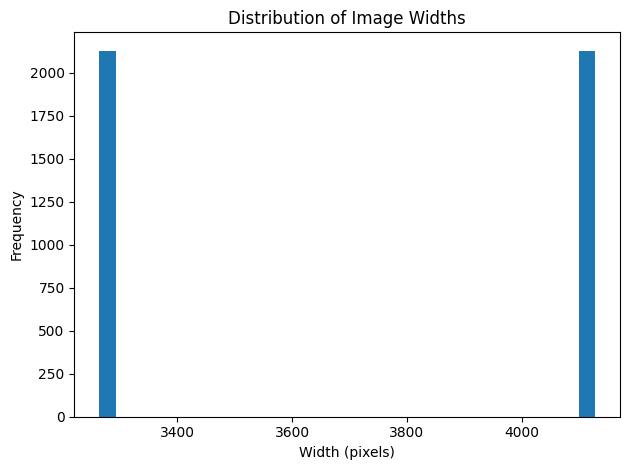

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['width'], bins=30)
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


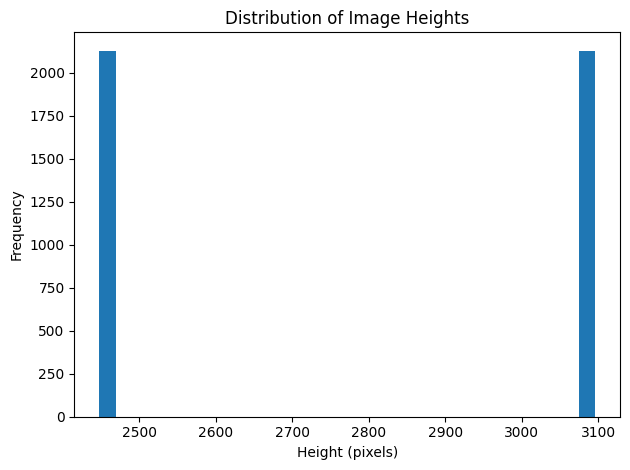

In [22]:
plt.figure()
plt.hist(df['height'], bins=30)
plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


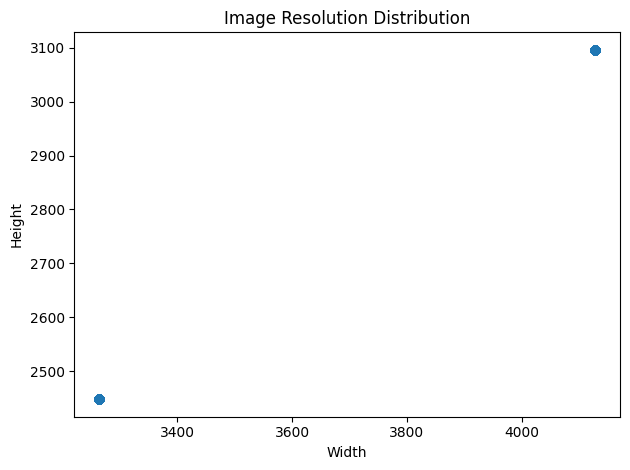

In [23]:
plt.figure()
plt.scatter(df['width'], df['height'])
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()


In [3]:
# =========================================================
# IMPORTS
# =========================================================
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.metrics import f1_score


# =========================================================
# DATASET
# =========================================================
class DocumentDataset(Dataset):
    def __init__(self, csv_file, image_root, transform=None):
        self.data = pd.read_csv(csv_file)
        self.image_root = image_root
        self.transform = transform

        self.label_cols = [
            "blur_motion",
            "blur_outfocus",
            "document_skew",
            "lighting_shadow"
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_rel_path = self.data.iloc[idx]["image_path"]
        img_path = os.path.join(self.image_root, img_rel_path)

        image = Image.open(img_path).convert("RGB")
        labels = self.data.iloc[idx][self.label_cols].values.astype(np.float32)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(labels)


# =========================================================
# TRANSFORMS
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =========================================================
# CUSTOM CNN MODEL
# =========================================================
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)

        return self.fc(x)   # logits


# =========================================================
# TRAIN / EVAL FUNCTIONS
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            preds_all.append(preds.cpu().numpy())
            labels_all.append(labels.cpu().numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro_f1 = f1_score(labels_all, preds_all, average="macro")
    micro_f1 = f1_score(labels_all, preds_all, average="micro")

    return macro_f1, micro_f1


# =========================================================
# MAIN TRAINING LOOP
# =========================================================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("🚀 Using device:", device)

    IMAGE_ROOT = "/kaggle/working/Final_Images_CROPPED"
    CSV_PATH = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/smartdocqa_multimodal_v2_clean (1).csv"

    train_ds = DocumentDataset(CSV_PATH, IMAGE_ROOT, train_transform)
    val_ds   = DocumentDataset(CSV_PATH, IMAGE_ROOT, val_transform)

    train_loader = DataLoader(
        train_ds, batch_size=32, shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_ds, batch_size=32, shuffle=False, num_workers=2
    )

    model = CustomCNN().to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    EPOCHS = 30

    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        macro_f1, micro_f1 = evaluate(model, val_loader, device)

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] | "
            f"Loss: {loss:.4f} | "
            f"Macro F1: {macro_f1:.4f} | "
            f"Micro F1: {micro_f1:.4f}"
        )

    torch.save(model.state_dict(), "custom_cnn_final.pth")
    print("✅ Model saved as custom_cnn_final.pth")


# =========================================================
# RUN
# =========================================================
if __name__ == "__main__":
    main()


🚀 Using device: cuda
Epoch [1/30] | Loss: 0.5795 | Macro F1: 0.5379 | Micro F1: 0.6680
Epoch [2/30] | Loss: 0.5398 | Macro F1: 0.5618 | Micro F1: 0.6760
Epoch [3/30] | Loss: 0.5109 | Macro F1: 0.5938 | Micro F1: 0.7214
Epoch [4/30] | Loss: 0.5021 | Macro F1: 0.5860 | Micro F1: 0.7183
Epoch [5/30] | Loss: 0.4946 | Macro F1: 0.5865 | Micro F1: 0.7049
Epoch [6/30] | Loss: 0.4973 | Macro F1: 0.6372 | Micro F1: 0.7425
Epoch [7/30] | Loss: 0.4865 | Macro F1: 0.5816 | Micro F1: 0.7057
Epoch [8/30] | Loss: 0.4804 | Macro F1: 0.6637 | Micro F1: 0.7481
Epoch [9/30] | Loss: 0.4757 | Macro F1: 0.6859 | Micro F1: 0.7606
Epoch [10/30] | Loss: 0.4756 | Macro F1: 0.6297 | Micro F1: 0.7445
Epoch [11/30] | Loss: 0.4767 | Macro F1: 0.6141 | Micro F1: 0.7326
Epoch [12/30] | Loss: 0.4654 | Macro F1: 0.5967 | Micro F1: 0.7129
Epoch [13/30] | Loss: 0.4553 | Macro F1: 0.6825 | Micro F1: 0.7537
Epoch [14/30] | Loss: 0.4548 | Macro F1: 0.6753 | Micro F1: 0.7514
Epoch [15/30] | Loss: 0.4567 | Macro F1: 0.6149 | 

# A0 - BASELINE

Imports ---- run for all ablations

In [3]:
import os
import cv2
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import f1_score, accuracy_score


Paths ----- run for all ablations

In [4]:
# Paths (adjust if needed)
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"
TRAIN_CSV = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/train.csv"
VAL_CSV   = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/val.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30


RESIZE ------ run before A1

In [28]:
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image_resized = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    image_padded = cv2.copyMakeBorder(
        image_resized,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]  # black padding
    )

    return image_padded


In [14]:
class DocumentDataset(Dataset):
    def __init__(self, csv_path, image_dir):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # image_path column from your CSV
        img_path = os.path.join(self.image_dir, row["image_path"])

        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        labels = torch.tensor([
            row["blur_motion"],
            row["blur_outfocus"],
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, labels


In [15]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(128, 4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = DocumentDataset(TRAIN_CSV, CROPPED_DIR)
val_dataset   = DocumentDataset(VAL_CSV, CROPPED_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [19]:
from sklearn.metrics import f1_score

def evaluate_macro_micro(model, val_loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    micro_f1 = f1_score(all_labels, all_preds, average="micro")

    return macro_f1, micro_f1


In [20]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    macro_f1, micro_f1 = evaluate_macro_micro(model, val_loader, device)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {avg_loss:.4f} | "
        f"Macro F1: {macro_f1:.4f} | "
        f"Micro F1: {micro_f1:.4f}"
    )


Epoch [1/30] | Loss: 0.5915 | Macro F1: 0.3947 | Micro F1: 0.6225
Epoch [2/30] | Loss: 0.5872 | Macro F1: 0.3816 | Micro F1: 0.6185
Epoch [3/30] | Loss: 0.5812 | Macro F1: 0.3978 | Micro F1: 0.6173
Epoch [4/30] | Loss: 0.5753 | Macro F1: 0.4228 | Micro F1: 0.6219
Epoch [5/30] | Loss: 0.5681 | Macro F1: 0.4387 | Micro F1: 0.6355
Epoch [6/30] | Loss: 0.5608 | Macro F1: 0.4304 | Micro F1: 0.6215
Epoch [7/30] | Loss: 0.5541 | Macro F1: 0.5192 | Micro F1: 0.6832
Epoch [8/30] | Loss: 0.5469 | Macro F1: 0.5298 | Micro F1: 0.6841
Epoch [9/30] | Loss: 0.5400 | Macro F1: 0.5240 | Micro F1: 0.6951
Epoch [10/30] | Loss: 0.5323 | Macro F1: 0.5222 | Micro F1: 0.6921
Epoch [11/30] | Loss: 0.5265 | Macro F1: 0.5790 | Micro F1: 0.7209
Epoch [12/30] | Loss: 0.5204 | Macro F1: 0.5639 | Micro F1: 0.7034
Epoch [13/30] | Loss: 0.5138 | Macro F1: 0.5635 | Micro F1: 0.7022
Epoch [14/30] | Loss: 0.5068 | Macro F1: 0.5912 | Micro F1: 0.7309
Epoch [15/30] | Loss: 0.5039 | Macro F1: 0.6129 | Micro F1: 0.7462
Epoc

In [21]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs).cpu().numpy() > 0.5

        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

categories = [
    "blur_motion",
    "blur_outfocus",
    "document_skew",
    "lighting_shadow"
]

print("\n=== BASELINE (A0) METRICS ===")
for i, cat in enumerate(categories):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cat:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")



=== BASELINE (A0) METRICS ===
blur_motion          | F1: 0.0000 | Acc: 0.7641
blur_outfocus        | F1: 0.7492 | Acc: 0.7359
document_skew        | F1: 0.7909 | Acc: 0.6667
lighting_shadow      | F1: 0.9175 | Acc: 0.9519


# A1 - FEATURE EMPHASIS

In [20]:
import os
import cv2
import numpy as np
from tqdm import tqdm

A1_DIR = "/kaggle/working/Final_Images_CROPPED_A1"
os.makedirs(A1_DIR, exist_ok=True)


In [18]:
def frequency_emphasis(image, alpha=0.8):
    emphasized = []

    for c in range(3):
        channel = image[:, :, c].astype(np.float32)

        f = np.fft.fft2(channel)
        fshift = np.fft.fftshift(f)

        rows, cols = channel.shape
        crow, ccol = rows // 2, cols // 2

        y, x = np.ogrid[:rows, :cols]
        distance = np.sqrt((y - crow)**2 + (x - ccol)**2)
        max_dist = np.max(distance)

        mask = 1 + alpha * (distance / max_dist)
        fshift_emph = fshift * mask

        f_ishift = np.fft.ifftshift(fshift_emph)
        img_back = np.fft.ifft2(f_ishift)
        img_back = np.real(img_back)

        img_back = np.clip(img_back, 0, 255)
        emphasized.append(img_back)

    emphasized = np.stack(emphasized, axis=2).astype(np.uint8)
    return emphasized


In [24]:
from tqdm import tqdm
import os
import cv2

image_extensions = (".jpg", ".jpeg", ".png")
count_new = 0
count_skipped = 0

for root, _, files in os.walk(CROPPED_DIR):
    for fname in files:
        if not fname.lower().endswith(image_extensions):
            continue

        src_path = os.path.join(root, fname)

        # preserve relative path
        rel_path = os.path.relpath(src_path, CROPPED_DIR)
        dst_path = os.path.join(A1_DIR, rel_path)

        # skip if already processed
        if os.path.exists(dst_path):
            count_skipped += 1
            continue

        os.makedirs(os.path.dirname(dst_path), exist_ok=True)

        image = cv2.imread(src_path)
        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = frequency_emphasis(image, alpha=0.8)

        cv2.imwrite(dst_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
        count_new += 1

print("Newly processed images:", count_new)
print("Already existing images skipped:", count_skipped)


Newly processed images: 787
Already existing images skipped: 3473


In [25]:
def count_images(root):
    count = 0
    for _, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                count += 1
    return count

print("Original cropped images:", count_images(CROPPED_DIR))
print("A1 frequency-emphasized images:", count_images(A1_DIR))


Original cropped images: 4260
A1 frequency-emphasized images: 4260


In [34]:
A1_DIR = "/kaggle/working/Final_Images_CROPPED_A1"

TRAIN_CSV = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/train.csv"
VAL_CSV   = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/val.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 40


In [27]:
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image_resized = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    image_padded = cv2.copyMakeBorder(
        image_resized,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )

    return image_padded


Dataset Class

In [28]:
class DocumentDataset(Dataset):
    def __init__(self, csv_path, image_dir):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_dir, row["image_path"])
        image = cv2.imread(img_path)

        if image is None:
            raise FileNotFoundError(f"Missing image: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        labels = torch.tensor([
            row["blur_motion"],
            row["blur_outfocus"],
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, labels


#sanitycheck

In [29]:
dataset = DocumentDataset(TRAIN_CSV, A1_DIR)
img, lbl = dataset[0]

print(img.shape)
print(lbl)


torch.Size([3, 224, 224])
tensor([0., 0., 0., 0.])


In [ ]:
MODEL ----- same as previous ablation

In [30]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(128, 4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


Loaders + Training Setup

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = DocumentDataset(TRAIN_CSV, A1_DIR)
val_dataset   = DocumentDataset(VAL_CSV, A1_DIR)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Evaluation Function

In [32]:
def evaluate_macro_micro(model, val_loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    micro_f1 = f1_score(all_labels, all_preds, average="micro")

    return macro_f1, micro_f1


Training

In [35]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    macro_f1, micro_f1 = evaluate_macro_micro(model, val_loader, device)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {avg_loss:.4f} | "
        f"Macro F1: {macro_f1:.4f} | "
        f"Micro F1: {micro_f1:.4f}"
    )


Epoch [1/40] | Loss: 0.5973 | Macro F1: 0.4123 | Micro F1: 0.6271
Epoch [2/40] | Loss: 0.5925 | Macro F1: 0.3741 | Micro F1: 0.5937
Epoch [3/40] | Loss: 0.5877 | Macro F1: 0.3568 | Micro F1: 0.5931
Epoch [4/40] | Loss: 0.5804 | Macro F1: 0.4368 | Micro F1: 0.6277
Epoch [5/40] | Loss: 0.5739 | Macro F1: 0.4341 | Micro F1: 0.6511
Epoch [6/40] | Loss: 0.5680 | Macro F1: 0.4462 | Micro F1: 0.6391
Epoch [7/40] | Loss: 0.5615 | Macro F1: 0.4885 | Micro F1: 0.6653
Epoch [8/40] | Loss: 0.5542 | Macro F1: 0.4301 | Micro F1: 0.6326
Epoch [9/40] | Loss: 0.5478 | Macro F1: 0.5256 | Micro F1: 0.6940
Epoch [10/40] | Loss: 0.5427 | Macro F1: 0.5364 | Micro F1: 0.6825
Epoch [11/40] | Loss: 0.5375 | Macro F1: 0.5506 | Micro F1: 0.7019
Epoch [12/40] | Loss: 0.5310 | Macro F1: 0.5094 | Micro F1: 0.6770
Epoch [13/40] | Loss: 0.5263 | Macro F1: 0.5354 | Micro F1: 0.6921
Epoch [14/40] | Loss: 0.5217 | Macro F1: 0.5759 | Micro F1: 0.7258
Epoch [15/40] | Loss: 0.5167 | Macro F1: 0.5894 | Micro F1: 0.7309


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7da9ef777c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Epoch [16/40] | Loss: 0.5116 | Macro F1: 0.5719 | Micro F1: 0.7104
Epoch [17/40] | Loss: 0.5079 | Macro F1: 0.6033 | Micro F1: 0.7444
Epoch [18/40] | Loss: 0.5065 | Macro F1: 0.5969 | Micro F1: 0.7375
Epoch [19/40] | Loss: 0.4991 | Macro F1: 0.5956 | Micro F1: 0.7303
Epoch [20/40] | Loss: 0.4967 | Macro F1: 0.5883 | Micro F1: 0.7325
Epoch [21/40] | Loss: 0.4930 | Macro F1: 0.5930 | Micro F1: 0.7283
Epoch [22/40] | Loss: 0.4913 | Macro F1: 0.6035 | Micro F1: 0.7347
Epoch [23/40] | Loss: 0.4865 | Macro F1: 0.5742 | Micro F1: 0.7103
Epoch [24/40] | Loss: 0.4852 | Macro F1: 0.6041 | Micro F1: 0.7411
Epoch [25/40] | Loss: 0.4834 | Macro F1: 0.6038 | Micro F1: 0.7418
Epoch [26/40] | Loss: 0.4776 | Macro F1: 0.6194 | Micro F1: 0.7547
Epoch [27/40] | Loss: 0.4782 | Macro F1: 0.6002 | Micro F1: 0.7337
Epoch [28/40] | Loss: 0.4772 | Macro F1: 0.6150 | Micro F1: 0.7459
Epoch [29/40] | Loss: 0.4733 | Macro F1: 0.6247 | Micro F1: 0.7586
Epoch [30/40] | Loss: 0.4701 | Macro F1: 0.6226 | Micro F1: 0.

In [36]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

categories = [
    "blur_motion",
    "blur_outfocus",
    "document_skew",
    "lighting_shadow"
]

print("\n=== A1 (Frequency Emphasis) METRICS ===")
for i, cat in enumerate(categories):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cat:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")



=== A1 (Frequency Emphasis) METRICS ===
blur_motion          | F1: 0.0000 | Acc: 0.7641
blur_outfocus        | F1: 0.7189 | Acc: 0.7218
document_skew        | F1: 0.7959 | Acc: 0.6714
lighting_shadow      | F1: 0.9656 | Acc: 0.9789


# A2: LOSS WEIGHTED TRAINING

In [2]:
import os
import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, accuracy_score


In [3]:
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_CSV = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/train.csv"
VAL_CSV   = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/val.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 40


In [4]:
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image_resized = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    image_padded = cv2.copyMakeBorder(
        image_resized,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )
    return image_padded


In [5]:
class DocumentDataset(Dataset):
    def __init__(self, csv_path, image_dir):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_dir, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        labels = torch.tensor([
            row["blur_motion"],
            row["blur_outfocus"],
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, labels


In [6]:
dataset = DocumentDataset(TRAIN_CSV, CROPPED_DIR)
img, lbl = dataset[0]
print(img.shape)
print(lbl)


torch.Size([3, 224, 224])
tensor([0., 0., 0., 0.])


In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = DocumentDataset(TRAIN_CSV, CROPPED_DIR)
val_dataset   = DocumentDataset(VAL_CSV, CROPPED_DIR)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [9]:
class_weights = torch.tensor(
    [3.0, 1.0, 1.0, 1.0],  # blur_motion emphasized
    device=device
)

criterion = nn.BCEWithLogitsLoss(reduction="none")


In [10]:
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [11]:
def evaluate_macro_micro(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    macro = f1_score(all_labels, all_preds, average="macro")
    micro = f1_score(all_labels, all_preds, average="micro")
    return macro, micro


In [12]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss_raw = criterion(outputs, labels)
        loss_weighted = loss_raw * class_weights
        loss = loss_weighted.mean()

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    macro_f1, micro_f1 = evaluate_macro_micro(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {avg_loss:.4f} | "
        f"Macro F1: {macro_f1:.4f} | "
        f"Micro F1: {micro_f1:.4f}"
    )


Epoch [1/40] | Loss: 0.9243 | Macro F1: 0.2006 | Micro F1: 0.4954
Epoch [2/40] | Loss: 0.8978 | Macro F1: 0.2006 | Micro F1: 0.4954
Epoch [3/40] | Loss: 0.8947 | Macro F1: 0.2006 | Micro F1: 0.4954
Epoch [4/40] | Loss: 0.8912 | Macro F1: 0.2006 | Micro F1: 0.4954
Epoch [5/40] | Loss: 0.8871 | Macro F1: 0.2626 | Micro F1: 0.5290
Epoch [6/40] | Loss: 0.8823 | Macro F1: 0.3867 | Micro F1: 0.6422
Epoch [7/40] | Loss: 0.8789 | Macro F1: 0.3284 | Micro F1: 0.5786
Epoch [8/40] | Loss: 0.8738 | Macro F1: 0.3865 | Micro F1: 0.6001
Epoch [9/40] | Loss: 0.8693 | Macro F1: 0.3494 | Micro F1: 0.5970
Epoch [10/40] | Loss: 0.8645 | Macro F1: 0.3706 | Micro F1: 0.5988
Epoch [11/40] | Loss: 0.8604 | Macro F1: 0.3824 | Micro F1: 0.6063
Epoch [12/40] | Loss: 0.8554 | Macro F1: 0.4373 | Micro F1: 0.6447
Epoch [13/40] | Loss: 0.8491 | Macro F1: 0.4223 | Micro F1: 0.6264
Epoch [14/40] | Loss: 0.8421 | Macro F1: 0.4706 | Micro F1: 0.6518
Epoch [15/40] | Loss: 0.8361 | Macro F1: 0.4442 | Micro F1: 0.6565
Epoc

In [13]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

categories = [
    "blur_motion",
    "blur_outfocus",
    "document_skew",
    "lighting_shadow"
]

print("\n=== A2 (Loss-Weighted Training) METRICS ===")
for i, cat in enumerate(categories):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cat:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")



=== A2 (Loss-Weighted Training) METRICS ===
blur_motion          | F1: 0.0000 | Acc: 0.7641
blur_outfocus        | F1: 0.7536 | Acc: 0.7160
document_skew        | F1: 0.8045 | Acc: 0.6761
lighting_shadow      | F1: 0.9677 | Acc: 0.9800


# B0: BASELINE

In [2]:
import os
import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, accuracy_score


In [3]:
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_CSV = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/train.csv"
VAL_CSV   = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/val.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30


In [4]:
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )


In [5]:
class DocumentDatasetMerged(Dataset):
    def __init__(self, csv_path, image_dir):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_dir, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # MERGED BLUR LABEL
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, labels


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 3)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = DocumentDatasetMerged(TRAIN_CSV, CROPPED_DIR)
val_dataset   = DocumentDatasetMerged(VAL_CSV, CROPPED_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [8]:
model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [9]:
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    return macro, micro


In [10]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    macro, micro = evaluate(model, val_loader)
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | Micro F1: {micro:.4f}"
    )


Epoch [1/30] | Loss: 0.6321 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [2/30] | Loss: 0.6129 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [3/30] | Loss: 0.6002 | Macro F1: 0.5499 | Micro F1: 0.7542
Epoch [4/30] | Loss: 0.5880 | Macro F1: 0.5543 | Micro F1: 0.7592
Epoch [5/30] | Loss: 0.5775 | Macro F1: 0.5542 | Micro F1: 0.7587
Epoch [6/30] | Loss: 0.5680 | Macro F1: 0.5552 | Micro F1: 0.7590
Epoch [7/30] | Loss: 0.5602 | Macro F1: 0.5814 | Micro F1: 0.7639
Epoch [8/30] | Loss: 0.5517 | Macro F1: 0.6010 | Micro F1: 0.7653
Epoch [9/30] | Loss: 0.5450 | Macro F1: 0.6029 | Micro F1: 0.7690
Epoch [10/30] | Loss: 0.5387 | Macro F1: 0.6796 | Micro F1: 0.7803
Epoch [11/30] | Loss: 0.5299 | Macro F1: 0.6560 | Micro F1: 0.7756
Epoch [12/30] | Loss: 0.5237 | Macro F1: 0.7702 | Micro F1: 0.8071
Epoch [13/30] | Loss: 0.5176 | Macro F1: 0.7643 | Micro F1: 0.8053
Epoch [14/30] | Loss: 0.5114 | Macro F1: 0.6851 | Micro F1: 0.7848
Epoch [15/30] | Loss: 0.5035 | Macro F1: 0.7440 | Micro F1: 0.8000
Epoc

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

classes = ["blur_present", "document_skew", "lighting_shadow"]

print("\n=== B0: MERGED BLUR RESULTS ===")
for i, cls in enumerate(classes):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cls:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")



=== B0: MERGED BLUR RESULTS ===
blur_present         | F1: 0.8811 | Acc: 0.8099
document_skew        | F1: 0.8009 | Acc: 0.6714
lighting_shadow      | F1: 0.9000 | Acc: 0.9390


In [12]:
torch.save(model.state_dict(), "B0_raw_baseline.pth")


# B2: HYBRID MODEL

In [13]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm


In [3]:
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_CSV = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/train.csv"
VAL_CSV   = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/val.csv"

OUT_TRAIN_CSV = "/kaggle/working/train_blur_features_cropped.csv"
OUT_VAL_CSV   = "/kaggle/working/val_blur_features_cropped.csv"


In [4]:
def var_laplacian(gray):
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def tenengrad(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return np.mean(gx**2 + gy**2)


def brenner(gray):
    return np.sum((gray[:, 2:] - gray[:, :-2]) ** 2)


def fft_highfreq_ratio(gray):
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)

    h, w = gray.shape
    cx, cy = h // 2, w // 2
    radius = min(cx, cy) // 3

    Y, X = np.ogrid[:h, :w]
    mask = (X - cy)**2 + (Y - cx)**2 > radius**2

    high_freq_energy = magnitude[mask].sum()
    total_energy = magnitude.sum()

    return high_freq_energy / (total_energy + 1e-8)


In [5]:
def compute_features(csv_path, image_root, out_csv):
    df = pd.read_csv(csv_path)
    rows = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(image_root, row["image_path"])
        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features = {
            "image_path": row["image_path"],

            # blur features
            "var_laplacian": var_laplacian(gray),
            "tenengrad": tenengrad(gray),
            "brenner": brenner(gray),
            "fft_highfreq_ratio": fft_highfreq_ratio(gray),

            # labels
            "blur_motion": row["blur_motion"],
            "blur_outfocus": row["blur_outfocus"],
            "document_skew": row["document_skew"],
            "lighting_shadow": row["lighting_shadow"]
        }

        rows.append(features)

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")


In [6]:
compute_features(TRAIN_CSV, CROPPED_DIR, OUT_TRAIN_CSV)
compute_features(VAL_CSV, CROPPED_DIR, OUT_VAL_CSV)


100%|██████████| 3408/3408 [37:49<00:00,  1.50it/s] 


Saved: /kaggle/working/train_blur_features_cropped.csv


100%|██████████| 852/852 [09:33<00:00,  1.49it/s]

Saved: /kaggle/working/val_blur_features_cropped.csv


In [7]:
df = pd.read_csv(OUT_TRAIN_CSV)
print(df.head())
print(df.columns)


                                          image_path  var_laplacian  \
0   Nokia_phone/Images/M_Img_WP_D23_L3_r35_a0_b0.jpg     301.894114   
1  Samsung_phone/Images/M_Img_Android_D26_L3_r35_...      19.123922   
2  Samsung_phone/Images/M_Img_Android_D8_L4_r35_a...      37.639072   
3  Nokia_phone/Images/M_Img_WP_D13_L3_r35_a-5_b10...     168.984223   
4  Samsung_phone/Images/M_Img_Android_D11_L3_r35_...     135.210483   

     tenengrad    brenner  fft_highfreq_ratio  blur_motion  blur_outfocus  \
0  2487.653528  212252897            0.725581            0              0   
1   247.202666   62388230            0.531549            0              1   
2   572.062991   58464302            0.594661            0              1   
3  3316.219752  101953460            0.609358            0              0   
4  3742.951159   86994686            0.551501            0              0   

   document_skew  lighting_shadow  
0              0                0  
1              0                0  
2 

In [14]:
import os
import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, accuracy_score


In [15]:
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_FEATURES = "/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30


In [16]:
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )


In [17]:
train_df = pd.read_csv(TRAIN_FEATURES)
val_df   = pd.read_csv(VAL_FEATURES)

FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio"
]

feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8


In [18]:
class HybridDataset(Dataset):
    def __init__(self, df, image_root, mean, std):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ---------- IMAGE ----------
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # ---------- NUMERIC FEATURES ----------
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # ---------- MERGED LABELS ----------
        blur_present = int(row["blur_motion"] == 1 or row["blur_outfocus"] == 1)

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, feats, labels


In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = HybridDataset(train_df, CROPPED_DIR, feat_mean, feat_std)
val_dataset   = HybridDataset(val_df, CROPPED_DIR, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [20]:
class HybridCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Image branch
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Numeric branch
        self.num_fc = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU()
        )

        # Fusion
        self.classifier = nn.Linear(128 + 16, 3)

    def forward(self, image, features):
        x_img = self.cnn(image)
        x_img = x_img.view(x_img.size(0), -1)

        x_num = self.num_fc(features)

        x = torch.cat([x_img, x_num], dim=1)
        return self.classifier(x)


In [21]:
model = HybridCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [22]:
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, feats, labels in loader:
            images = images.to(device)
            feats = feats.to(device)
            outputs = model(images, feats)

            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    return macro, micro


In [23]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, feats, labels in train_loader:
        images = images.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    macro, micro = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | Micro F1: {micro:.4f}"
    )


Epoch [1/30] | Loss: 0.6253 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [2/30] | Loss: 0.6096 | Macro F1: 0.5484 | Micro F1: 0.7525
Epoch [3/30] | Loss: 0.5959 | Macro F1: 0.5537 | Micro F1: 0.7583
Epoch [4/30] | Loss: 0.5846 | Macro F1: 0.5536 | Micro F1: 0.7582
Epoch [5/30] | Loss: 0.5754 | Macro F1: 0.5540 | Micro F1: 0.7581
Epoch [6/30] | Loss: 0.5664 | Macro F1: 0.5599 | Micro F1: 0.7599
Epoch [7/30] | Loss: 0.5586 | Macro F1: 0.5582 | Micro F1: 0.7604
Epoch [8/30] | Loss: 0.5505 | Macro F1: 0.6264 | Micro F1: 0.7748
Epoch [9/30] | Loss: 0.5393 | Macro F1: 0.6859 | Micro F1: 0.7872
Epoch [10/30] | Loss: 0.5291 | Macro F1: 0.6881 | Micro F1: 0.7893
Epoch [11/30] | Loss: 0.5193 | Macro F1: 0.7727 | Micro F1: 0.8115
Epoch [12/30] | Loss: 0.5081 | Macro F1: 0.7774 | Micro F1: 0.8097
Epoch [13/30] | Loss: 0.4972 | Macro F1: 0.7934 | Micro F1: 0.8194
Epoch [14/30] | Loss: 0.4850 | Macro F1: 0.8061 | Micro F1: 0.8214
Epoch [15/30] | Loss: 0.4770 | Macro F1: 0.8439 | Micro F1: 0.8388
Epoc

In [24]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, feats, labels in val_loader:
        images = images.to(device)
        feats = feats.to(device)
        outputs = model(images, feats)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

classes = ["blur_present", "document_skew", "lighting_shadow"]

print("\n=== B1 (Hybrid Model) RESULTS ===")
for i, cls in enumerate(classes):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cls:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")



=== B1 (Hybrid Model) RESULTS ===
blur_present         | F1: 0.8867 | Acc: 0.8239
document_skew        | F1: 0.7848 | Acc: 0.6620
lighting_shadow      | F1: 0.8980 | Acc: 0.9413


In [25]:
torch.save(model.state_dict(), "B2_hybrid.pth")


# B3: HYBRID + skew

In [26]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm


In [2]:
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_CSV = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/train.csv"
VAL_CSV   = "/kaggle/input/smartdocqa-diqa/Dataset SmartDoc-QA/val.csv"

OUT_TRAIN_CSV = "/kaggle/working/train_blur_features_cropped_B3.csv"
OUT_VAL_CSV   = "/kaggle/working/val_blur_features_cropped_B3.csv"


In [8]:
def var_laplacian(gray):
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def tenengrad(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return np.mean(gx**2 + gy**2)


def brenner(gray):
    return np.sum((gray[:, 2:] - gray[:, :-2]) ** 2)


def fft_highfreq_ratio(gray):
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)

    h, w = gray.shape
    cx, cy = h // 2, w // 2
    radius = min(cx, cy) // 3

    Y, X = np.ogrid[:h, :w]
    mask = (X - cy)**2 + (Y - cx)**2 > radius**2

    high_freq_energy = magnitude[mask].sum()
    total_energy = magnitude.sum()

    return high_freq_energy / (total_energy + 1e-8)
def directional_gradient_ratio(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    mean_x = np.mean(np.abs(gx))
    mean_y = np.mean(np.abs(gy))

    return mean_x / (mean_y + 1e-8)
def skew_hough_angle(gray):
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)

    if lines is None:
        return 0.0

    angles = []
    for line in lines[:20]:
        rho, theta = line[0]
        angle = theta - np.pi / 2
        angles.append(angle)

    return np.mean(angles)


In [4]:
def compute_features(csv_path, image_root, out_csv):
    df = pd.read_csv(csv_path)
    rows = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(image_root, row["image_path"])
        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features = {
            "image_path": row["image_path"],

            # --- blur features ---
            "var_laplacian": var_laplacian(gray),
            "tenengrad": tenengrad(gray),
            "brenner": brenner(gray),
            "fft_highfreq_ratio": fft_highfreq_ratio(gray),

            # --- NEW features ---
            "directional_grad_ratio": directional_gradient_ratio(gray),
            "skew_hough_angle": skew_hough_angle(gray),

            # labels
            "blur_motion": row["blur_motion"],
            "blur_outfocus": row["blur_outfocus"],
            "document_skew": row["document_skew"],
            "lighting_shadow": row["lighting_shadow"]
        }

        rows.append(features)

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")


In [7]:
compute_features(TRAIN_CSV, CROPPED_DIR, OUT_TRAIN_CSV)
compute_features(VAL_CSV, CROPPED_DIR, OUT_VAL_CSV)


100%|██████████| 3408/3408 [46:11<00:00,  1.23it/s] 


Saved: /kaggle/working/train_blur_features_cropped_B3.csv


100%|██████████| 852/852 [11:39<00:00,  1.22it/s]

Saved: /kaggle/working/val_blur_features_cropped_B3.csv


In [7]:
df = pd.read_csv(OUT_TRAIN_CSV)
print(df.columns)
print(df.head())


Index(['image_path', 'var_laplacian', 'tenengrad', 'brenner',
       'fft_highfreq_ratio', 'directional_grad_ratio', 'skew_hough_angle',
       'blur_motion', 'blur_outfocus', 'document_skew', 'lighting_shadow'],
      dtype='object')
                                          image_path  var_laplacian  \
0   Nokia_phone/Images/M_Img_WP_D23_L3_r35_a0_b0.jpg     301.894114   
1  Samsung_phone/Images/M_Img_Android_D26_L3_r35_...      19.123922   
2  Samsung_phone/Images/M_Img_Android_D8_L4_r35_a...      37.639072   
3  Nokia_phone/Images/M_Img_WP_D13_L3_r35_a-5_b10...     168.984223   
4  Samsung_phone/Images/M_Img_Android_D11_L3_r35_...     135.210483   

     tenengrad    brenner  fft_highfreq_ratio  directional_grad_ratio  \
0  2487.653528  212252897            0.725581                1.001415   
1   247.202666   62388230            0.531549                0.951520   
2   572.062991   58464302            0.594661                1.067426   
3  3316.219752  101953460            0.609358 

In [8]:
import os
import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, accuracy_score


In [27]:
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_FEATURES = "//kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30


In [28]:
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )


In [29]:
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()

FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle"
]

feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8


In [30]:
class HybridDatasetB3(Dataset):
    def __init__(self, df, image_root, mean, std):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ----- IMAGE -----
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # ----- NUMERIC FEATURES -----
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # ----- MERGED LABELS -----
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, feats, labels


In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = HybridDatasetB3(train_df, CROPPED_DIR, feat_mean, feat_std)
val_dataset   = HybridDatasetB3(val_df, CROPPED_DIR, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [32]:
class HybridCNNB3(nn.Module):
    def __init__(self):
        super().__init__()

        # Image branch
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Numeric branch (6 features)
        self.num_fc = nn.Sequential(
            nn.Linear(6, 16),
            nn.ReLU()
        )

        # Fusion
        self.classifier = nn.Linear(128 + 16, 3)

    def forward(self, image, features):
        x_img = self.cnn(image)
        x_img = x_img.view(x_img.size(0), -1)

        x_num = self.num_fc(features)

        x = torch.cat([x_img, x_num], dim=1)
        return self.classifier(x)


In [33]:
model = HybridCNNB3().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [34]:
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, feats, labels in loader:
            images = images.to(device)
            feats = feats.to(device)
            outputs = model(images, feats)

            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    return macro, micro


In [35]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, feats, labels in train_loader:
        images = images.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    macro, micro = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | Micro F1: {micro:.4f}"
    )


Epoch [1/30] | Loss: 0.6215 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [2/30] | Loss: 0.6037 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [3/30] | Loss: 0.5898 | Macro F1: 0.5494 | Micro F1: 0.7536
Epoch [4/30] | Loss: 0.5748 | Macro F1: 0.5543 | Micro F1: 0.7590
Epoch [5/30] | Loss: 0.5607 | Macro F1: 0.5563 | Micro F1: 0.7611
Epoch [6/30] | Loss: 0.5467 | Macro F1: 0.5746 | Micro F1: 0.7655
Epoch [7/30] | Loss: 0.5319 | Macro F1: 0.7514 | Micro F1: 0.8065
Epoch [8/30] | Loss: 0.5159 | Macro F1: 0.6972 | Micro F1: 0.7897
Epoch [9/30] | Loss: 0.5029 | Macro F1: 0.7480 | Micro F1: 0.8043
Epoch [10/30] | Loss: 0.4854 | Macro F1: 0.8321 | Micro F1: 0.8360
Epoch [11/30] | Loss: 0.4693 | Macro F1: 0.7731 | Micro F1: 0.8130
Epoch [12/30] | Loss: 0.4576 | Macro F1: 0.8354 | Micro F1: 0.8392
Epoch [13/30] | Loss: 0.4442 | Macro F1: 0.8362 | Micro F1: 0.8392
Epoch [14/30] | Loss: 0.4340 | Macro F1: 0.8682 | Micro F1: 0.8548
Epoch [15/30] | Loss: 0.4275 | Macro F1: 0.8566 | Micro F1: 0.8485
Epoc

In [18]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, feats, labels in val_loader:
        images = images.to(device)
        feats = feats.to(device)
        outputs = model(images, feats)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

classes = ["blur_present", "document_skew", "lighting_shadow"]

print("\n=== B3 (Hybrid + Motion + Skew) RESULTS ===")
for i, cls in enumerate(classes):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cls:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")



=== B3 (Hybrid + Motion + Skew) RESULTS ===
blur_present         | F1: 0.8978 | Acc: 0.8439
document_skew        | F1: 0.8012 | Acc: 0.6878
lighting_shadow      | F1: 0.9518 | Acc: 0.9707


In [36]:
torch.save(model.state_dict(), "B3_hybrid_motion_skew.pth")


In [5]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

# ==============================
# FINAL VALIDATION EVALUATION
# ==============================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, feats, labels in val_loader:
        images = images.to(device)
        feats = feats.to(device)

        outputs = model(images, feats)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

classes = ["blur_present", "document_skew", "lighting_shadow"]

print("\n=== B3 (Hybrid + Motion + Skew) RESULTS ===")
print("-" * 55)

for i, cls in enumerate(classes):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cls:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")

# ==============================
# Macro & Micro Overall
# ==============================
macro_f1 = f1_score(all_labels, all_preds, average="macro")
micro_f1 = f1_score(all_labels, all_preds, average="micro")

print("-" * 55)
print(f"{'MACRO F1':20s} | {macro_f1:.4f}")
print(f"{'MICRO F1':20s} | {micro_f1:.4f}")



=== B3 (Hybrid + Motion + Skew) RESULTS ===
-------------------------------------------------------
blur_present         | F1: 0.9423 | Acc: 0.9167
document_skew        | F1: 0.8228 | Acc: 0.7230
lighting_shadow      | F1: 0.9811 | Acc: 0.9883
-------------------------------------------------------
MACRO F1             | 0.9154
MICRO F1             | 0.8975


# B4 : skew_metric version_2

In [9]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

FEATURE_CSV = "/kaggle/working/train_blur_features_cropped_B3.csv"
IMAGE_ROOT = "/kaggle/working/Final_Images_CROPPED"


In [10]:

df = pd.read_csv(FEATURE_CSV)


In [11]:
def skew_hough_angle_dilated(gray):
    kernel = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(gray, kernel, iterations=1)

    edges = cv2.Canny(dilated, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)

    if lines is None:
        return 0.0

    angles = []
    for line in lines[:20]:
        rho, theta = line[0]
        angles.append(theta - np.pi / 2)

    return float(np.mean(angles))
/

()

In [12]:
dilated_skew_vals = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(IMAGE_ROOT, row["image_path"])
    img = cv2.imread(img_path)

    if img is None:
        dilated_skew_vals.append(0.0)
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    dilated_skew_vals.append(skew_hough_angle_dilated(gray))


100%|██████████| 3408/3408 [05:20<00:00, 10.63it/s]


In [13]:
df["skew_hough_angle_dilated"] = dilated_skew_vals
OUT_CSV = "/kaggle/working/train_blur_features_cropped_B4.csv"
df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)


Saved: /kaggle/working/train_blur_features_cropped_B4.csv


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# -------------------------
# PATHS
# -------------------------
VAL_FEATURE_CSV = "/kaggle/input/val-blur-features-cropped-b3/val_blur_features_cropped_B3.csv"
OUT_VAL_CSV     = "/kaggle/working/val_blur_features_cropped_B4.csv"
IMAGE_ROOT      = "/kaggle/working/Final_Images_CROPPED"

# -------------------------
# DILATED SKEW FUNCTION
# -------------------------
def skew_hough_angle_dilated(gray):
    kernel = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(gray, kernel, iterations=1)

    edges = cv2.Canny(dilated, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)

    if lines is None:
        return 0.0

    angles = []
    for line in lines[:20]:
        rho, theta = line[0]
        angles.append(theta - np.pi / 2)

    return float(np.mean(angles))

# -------------------------
# LOAD VAL FEATURES
# -------------------------
df = pd.read_csv(VAL_FEATURE_CSV)

# -------------------------
# COMPUTE NEW COLUMN ONLY
# -------------------------
dilated_skew_vals = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(IMAGE_ROOT, row["image_path"])
    img = cv2.imread(img_path)

    if img is None:
        dilated_skew_vals.append(0.0)
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    dilated_skew_vals.append(skew_hough_angle_dilated(gray))

# -------------------------
# APPEND + SAVE
# -------------------------
df["skew_hough_angle_dilated"] = dilated_skew_vals
df.to_csv(OUT_VAL_CSV, index=False)

print("Saved VAL B4 features to:", OUT_VAL_CSV)


100%|██████████| 852/852 [01:14<00:00, 11.38it/s]

Saved VAL B4 features to: /kaggle/working/val_blur_features_cropped_B4.csv


In [4]:
# =====================================================
# B4 HYBRID TRAINING — ONE CELL (FINAL, CLEAN)
# =====================================================

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score

# -------------------------
# PATHS & CONSTANTS
# -------------------------
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_CSV = "/kaggle/input/b4-numeric-feature/train_blur_features_cropped_B4.csv"
VAL_CSV   = "/kaggle/working/val_blur_features_cropped_B4.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30

device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# RESIZE WITH PADDING
# -------------------------
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)
    nh, nw = int(h * scale), int(w * scale)
    image = cv2.resize(image, (nw, nh))

    top = (target_size - nh) // 2
    bottom = target_size - nh - top
    left = (target_size - nw) // 2
    right = target_size - nw - left

    return cv2.copyMakeBorder(
        image, top, bottom, left, right,
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )

# -------------------------
# LOAD FEATURE CSVs
# -------------------------
train_df = pd.read_csv(TRAIN_CSV).dropna().reset_index(drop=True)
val_df   = pd.read_csv(VAL_CSV).dropna().reset_index(drop=True)

# -------------------------
# FEATURE COLUMNS (B4)
# -------------------------
FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle",
    "skew_hough_angle_dilated"
]

# Normalize using TRAIN statistics only
feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8

# -------------------------
# DATASET
# -------------------------
class HybridDatasetB4(Dataset):
    def __init__(self, df, image_root, mean, std):
        self.df = df
        self.image_root = image_root
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img_path = os.path.join(self.image_root, row["image_path"])
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = resize_with_padding(img, IMG_SIZE)
        img = img / 255.0
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

        # Numeric features
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # Labels (merged blur)
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor(
            [blur_present, row["document_skew"], row["lighting_shadow"]],
            dtype=torch.float32
        )

        return img, feats, labels

# -------------------------
# DATALOADERS
# -------------------------
train_loader = DataLoader(
    HybridDatasetB4(train_df, CROPPED_DIR, feat_mean, feat_std),
    batch_size=BATCH_SIZE, shuffle=True
)

val_loader = DataLoader(
    HybridDatasetB4(val_df, CROPPED_DIR, feat_mean, feat_std),
    batch_size=BATCH_SIZE, shuffle=False
)

# -------------------------
# MODEL
# -------------------------
class HybridCNNB4(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.num_fc = nn.Sequential(
            nn.Linear(7, 16),
            nn.ReLU()
        )

        self.classifier = nn.Linear(128 + 16, 3)

    def forward(self, img, feats):
        x_img = self.cnn(img).view(img.size(0), -1)
        x_num = self.num_fc(feats)
        x = torch.cat([x_img, x_num], dim=1)
        return self.classifier(x)

model = HybridCNNB4().to(device)

# -------------------------
# TRAINING SETUP
# -------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# -------------------------
# EVALUATION FUNCTION
# -------------------------
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for imgs, feats, labels in loader:
            imgs, feats = imgs.to(device), feats.to(device)
            outputs = model(imgs, feats)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    return macro, micro

# -------------------------
# TRAIN LOOP
# -------------------------
for epoch in range(EPOCHS):
    model.train()
    loss_sum = 0.0

    for imgs, feats, labels in train_loader:
        imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

    macro, micro = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {loss_sum/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | Micro F1: {micro:.4f}"
    )

# -------------------------
# FINAL PER-CLASS METRICS
# -------------------------
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, feats, labels in val_loader:
        imgs, feats = imgs.to(device), feats.to(device)
        outputs = model(imgs, feats)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

classes = ["blur_present", "document_skew", "lighting_shadow"]

print("\n=== B4 (Hybrid + Dilated Skew) RESULTS ===")
for i, cls in enumerate(classes):
    f1 = f1_score(all_labels[:, i], all_preds[:, i])
    acc = accuracy_score(all_labels[:, i], all_preds[:, i])
    print(f"{cls:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")


Epoch [1/30] | Loss: 0.6250 | Macro F1: 0.5465 | Micro F1: 0.7501
Epoch [2/30] | Loss: 0.6026 | Macro F1: 0.5480 | Micro F1: 0.7520
Epoch [3/30] | Loss: 0.5886 | Macro F1: 0.5547 | Micro F1: 0.7598
Epoch [4/30] | Loss: 0.5738 | Macro F1: 0.5554 | Micro F1: 0.7599
Epoch [5/30] | Loss: 0.5632 | Macro F1: 0.5562 | Micro F1: 0.7565
Epoch [6/30] | Loss: 0.5541 | Macro F1: 0.6601 | Micro F1: 0.7816
Epoch [7/30] | Loss: 0.5455 | Macro F1: 0.6455 | Micro F1: 0.7779
Epoch [8/30] | Loss: 0.5357 | Macro F1: 0.6239 | Micro F1: 0.7764
Epoch [9/30] | Loss: 0.5264 | Macro F1: 0.5722 | Micro F1: 0.7678
Epoch [10/30] | Loss: 0.5164 | Macro F1: 0.7015 | Micro F1: 0.7930
Epoch [11/30] | Loss: 0.5071 | Macro F1: 0.6851 | Micro F1: 0.7879
Epoch [12/30] | Loss: 0.4948 | Macro F1: 0.6660 | Micro F1: 0.7837
Epoch [13/30] | Loss: 0.4870 | Macro F1: 0.7481 | Micro F1: 0.8085
Epoch [14/30] | Loss: 0.4762 | Macro F1: 0.7473 | Micro F1: 0.7985
Epoch [15/30] | Loss: 0.4674 | Macro F1: 0.8225 | Micro F1: 0.8307
Epoc

# B3:Augmented Hybrid training

In [7]:
# ==============================
# SAVE MODEL
# ==============================
MODEL_PATH = "/kaggle/working/B3_PRO_Hybrid_Model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "feature_mean": feat_mean,
    "feature_std": feat_std
}, MODEL_PATH)

print(f"\nModel saved at: {MODEL_PATH}")



Model saved at: /kaggle/working/B3_PRO_Hybrid_Model.pth


# NUMERIC BASELINE

In [1]:
# ==============================
# IMPORTS
# ==============================
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score

# ==============================
# SETTINGS
# ==============================
TRAIN_FEATURES = "/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================
# LOAD DATA
# ==============================
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()

FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle"
]

# Normalize features
feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8

# ==============================
# DATASET
# ==============================
class NumericDataset(Dataset):
    def __init__(self, df, mean, std):
        self.df = df.reset_index(drop=True)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Numeric features
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # Labels (same as your hybrid setup)
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return feats, labels


train_dataset = NumericDataset(train_df, feat_mean, feat_std)
val_dataset   = NumericDataset(val_df, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==============================
# MODEL
# ==============================
class NumericOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.model(x)


model = NumericOnlyModel().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================
# EVALUATION
# ==============================
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for feats, labels in loader:
            feats = feats.to(device)

            outputs = model(feats)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")

    return macro, micro, preds_all, labels_all

# ==============================
# TRAINING LOOP
# ==============================
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for feats, labels in train_loader:
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    macro, micro, _, _ = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | "
        f"Micro F1: {micro:.4f}"
    )

# ==============================
# FINAL METRICS
# ==============================
macro, micro, preds, gts = evaluate(model, val_loader)

print("\n=== NUMERIC BASELINE RESULTS ===")
labels = ["blur_present", "document_skew", "lighting_shadow"]

for i, lbl in enumerate(labels):
    print(
        f"{lbl:20s} | "
        f"F1: {f1_score(gts[:, i], preds[:, i]):.4f}"
    )

print("\nMacro F1:", macro)
print("Micro F1:", micro)

Epoch [1/30] | Loss: 0.6726 | Macro F1: 0.6241 | Micro F1: 0.6936
Epoch [2/30] | Loss: 0.6310 | Macro F1: 0.6043 | Micro F1: 0.7442
Epoch [3/30] | Loss: 0.5971 | Macro F1: 0.5795 | Micro F1: 0.7516
Epoch [4/30] | Loss: 0.5772 | Macro F1: 0.5795 | Micro F1: 0.7515
Epoch [5/30] | Loss: 0.5636 | Macro F1: 0.5604 | Micro F1: 0.7549
Epoch [6/30] | Loss: 0.5560 | Macro F1: 0.5610 | Micro F1: 0.7548
Epoch [7/30] | Loss: 0.5480 | Macro F1: 0.5638 | Micro F1: 0.7562
Epoch [8/30] | Loss: 0.5465 | Macro F1: 0.5849 | Micro F1: 0.7581
Epoch [9/30] | Loss: 0.5451 | Macro F1: 0.5882 | Micro F1: 0.7602
Epoch [10/30] | Loss: 0.5397 | Macro F1: 0.5906 | Micro F1: 0.7608
Epoch [11/30] | Loss: 0.5377 | Macro F1: 0.5949 | Micro F1: 0.7586
Epoch [12/30] | Loss: 0.5356 | Macro F1: 0.6002 | Micro F1: 0.7607
Epoch [13/30] | Loss: 0.5335 | Macro F1: 0.6001 | Micro F1: 0.7608
Epoch [14/30] | Loss: 0.5334 | Macro F1: 0.6669 | Micro F1: 0.7747
Epoch [15/30] | Loss: 0.5276 | Macro F1: 0.6583 | Micro F1: 0.7756
Epoc

In [3]:
import torch
import time
import os
import numpy as np

device = torch.device("cpu")

# -------------------------
# LOAD YOUR TRAINED MODEL
# -------------------------
model = NumericOnlyModel()
model.load_state_dict(
    torch.load("numeric_model.pth", map_location="cpu")  # save your model first
)
model.to(device)
model.eval()

# -------------------------
# UTILS
# -------------------------
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

def make_dummy_inputs(batch_size):
    return torch.randn(batch_size, 6).to(device)  # 🔥 6 features only

def measure_latency(model, batch_size, runs=20):
    feats = make_dummy_inputs(batch_size)

    # warm-up
    with torch.no_grad():
        for _ in range(5):
            _ = model(feats)

    times = []
    with torch.no_grad():
        for _ in range(runs):
            start = time.time()
            _ = model(feats)
            end = time.time()
            times.append(end - start)

    return np.mean(times)

# -------------------------
# RESULTS
# -------------------------
print("=== NUMERIC-ONLY BASELINE ===")

print("Parameters:", count_parameters(model))
print("Model size (MB):", model_size_mb("numeric_model.pth"))

for pages in [1, 2, 10, 100]:
    latency = measure_latency(model, pages)
    throughput = pages / latency
    print(f"{pages:3d} pages | Latency: {latency:.4f}s | Throughput: {throughput:.2f} pages/s")

=== NUMERIC-ONLY BASELINE ===
Parameters: 1443
Model size (MB): 0.01016998291015625
  1 pages | Latency: 0.0001s | Throughput: 10603.73 pages/s
  2 pages | Latency: 0.0001s | Throughput: 18333.75 pages/s
 10 pages | Latency: 0.0001s | Throughput: 101643.14 pages/s
100 pages | Latency: 0.0001s | Throughput: 1008003.85 pages/s


In [6]:
# ==============================
# SAVE MODEL
# ==============================
torch.save(model.state_dict(), "CBAM_model.pth")
print("✅ Numeric model saved as numeric_model.pth")

✅ Numeric model saved as numeric_model.pth


# FINAL PROPOSED HYBRID MODEL

USING DEVICE: cuda
GPU NAME: Tesla T4

Starting Training with Custom HybridCNN (Proposed Fusion)...

Epoch [1/30] | Train Loss: 0.6562 | Val Loss: 0.6129 | Val Macro F1: 0.5589 | Val Micro F1: 0.7484
Epoch [2/30] | Train Loss: 0.6009 | Val Loss: 0.5686 | Val Macro F1: 0.6758 | Val Micro F1: 0.7865
Epoch [3/30] | Train Loss: 0.5740 | Val Loss: 0.5397 | Val Macro F1: 0.6711 | Val Micro F1: 0.7855
Epoch [4/30] | Train Loss: 0.5581 | Val Loss: 0.5220 | Val Macro F1: 0.7460 | Val Micro F1: 0.8062
Epoch [5/30] | Train Loss: 0.5414 | Val Loss: 0.4957 | Val Macro F1: 0.7599 | Val Micro F1: 0.8131
Epoch [6/30] | Train Loss: 0.5207 | Val Loss: 0.4765 | Val Macro F1: 0.7923 | Val Micro F1: 0.8237
Epoch [7/30] | Train Loss: 0.5046 | Val Loss: 0.4641 | Val Macro F1: 0.7556 | Val Micro F1: 0.8152
Epoch [8/30] | Train Loss: 0.4695 | Val Loss: 0.4415 | Val Macro F1: 0.8445 | Val Micro F1: 0.8481
Epoch [9/30] | Train Loss: 0.4467 | Val Loss: 0.3905 | Val Macro F1: 0.8784 | Val Micro F1: 0.8675
Epoch [1

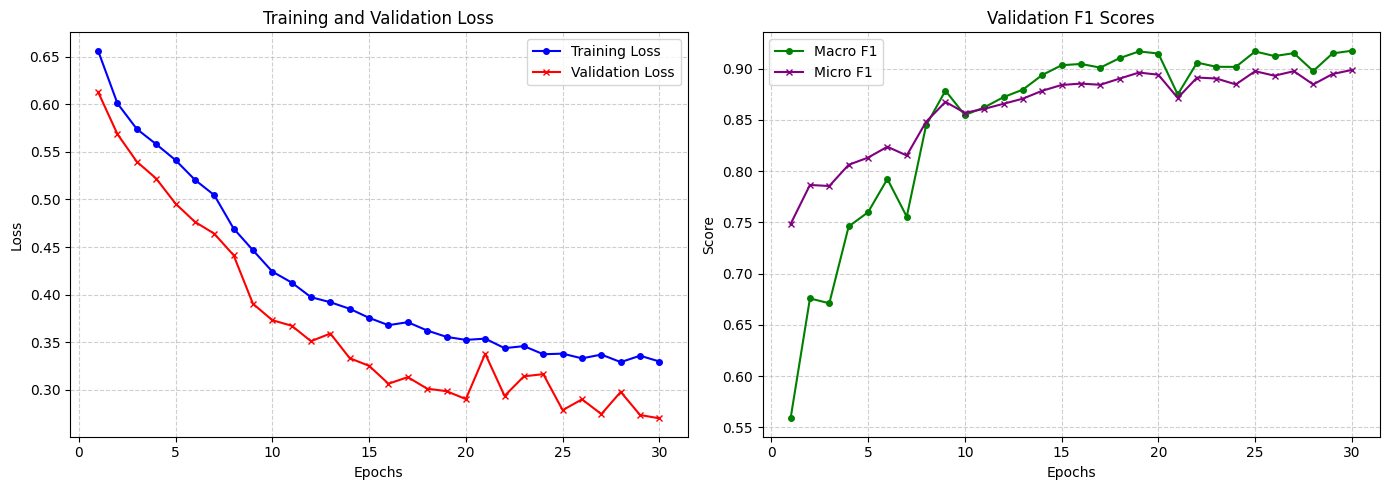

In [5]:
# ==============================
# IMPORTS
# ==============================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, accuracy_score

# ==============================
# DEVICE CHECK
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("========================================")
print(f"USING DEVICE: {device}")
if device.type == "cuda":
    print(f"GPU NAME: {torch.cuda.get_device_name(0)}")
print("========================================\n")

# ==============================
# PATHS & SETTINGS
# ==============================
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_FEATURES = "/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

# ==============================
# IMAGE RESIZE WITH PADDING
# ==============================
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )

# ==============================
# LOAD CSV
# ==============================
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()

FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle"
]

feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8

# ==============================
# DATASET
# ==============================
class HybridDataset(Dataset):
    def __init__(self, df, image_root, mean, std):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # IMAGE
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # NUMERIC FEATURES
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # LABELS
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, feats, labels

train_dataset = HybridDataset(train_df, CROPPED_DIR, feat_mean, feat_std)
val_dataset   = HybridDataset(val_df, CROPPED_DIR, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ==============================
# MODEL
# ==============================
class HybridCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Image Branch
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Numeric Branch
        self.num_fc = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),

            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(128 + 32, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 3)
        )

    def forward(self, image, features):
        x_img = self.cnn(image)
        x_img = x_img.view(x_img.size(0), -1)

        x_num = self.num_fc(features)

        x = torch.cat([x_img, x_num], dim=1)
        return self.fusion(x)

model = HybridCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================
# EVALUATION (Updated for Val Loss)
# ==============================
def evaluate(model, loader, criterion):
    model.eval()
    preds_all, labels_all = [], []
    val_loss = 0.0

    with torch.no_grad():
        for images, feats, labels in loader:
            images = images.to(device)
            feats = feats.to(device)
            labels = labels.to(device)

            outputs = model(images, feats)
            
            # Calculate validation loss
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            preds_all.append(preds)
            labels_all.append(labels.cpu().numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    
    avg_val_loss = val_loss / len(loader)

    return avg_val_loss, macro, micro, preds_all, labels_all

# ==============================
# TRACKERS FOR PLOTTING
# ==============================
history_train_loss = []
history_val_loss = []
history_val_macro = []
history_val_micro = []

# ==============================
# TRAINING LOOP
# ==============================
print("Starting Training with Custom HybridCNN (Proposed Fusion)...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, feats, labels in train_loader:
        images = images.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate average training loss for the epoch
    train_loss_epoch = running_loss / len(train_loader)
    
    # Evaluate on validation set
    val_loss_epoch, macro, micro, _, _ = evaluate(model, val_loader, criterion)

    # Save metrics to history
    history_train_loss.append(train_loss_epoch)
    history_val_loss.append(val_loss_epoch)
    history_val_macro.append(macro)
    history_val_micro.append(micro)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss_epoch:.4f} | "
        f"Val Loss: {val_loss_epoch:.4f} | "
        f"Val Macro F1: {macro:.4f} | "
        f"Val Micro F1: {micro:.4f}"
    )

# -------------------------
# FINAL METRICS
# -------------------------
final_val_loss, final_macro, final_micro, preds, gts = evaluate(model, val_loader, criterion)

print("\n=== B3 (Hybrid + Motion + Skew) RESULTS ===")
print("-------------------------------------------------------")
labels_names = ["blur_present", "document_skew", "lighting_shadow"]
for i, lbl in enumerate(labels_names):
    f1 = f1_score(gts[:, i], preds[:, i])
    acc = accuracy_score(gts[:, i], preds[:, i])
    print(f"{lbl:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")
print("-------------------------------------------------------")
print(f"MACRO F1             | {final_macro:.4f}")
print(f"MICRO F1             | {final_micro:.4f}")

# ==============================
# PLOT THE LEARNING CURVES
# ==============================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Training vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_train_loss, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, history_val_loss, label='Validation Loss', color='red', marker='x', markersize=4)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Validation F1 Scores
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_val_macro, label='Macro F1', color='green', marker='o', markersize=4)
plt.plot(epochs_range, history_val_micro, label='Micro F1', color='purple', marker='x', markersize=4)
plt.title('Validation F1 Scores')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Final model using a skew score

In [5]:
# ==============================
# IMPORTS
# ==============================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import f1_score, accuracy_score

# ==============================
# SETTINGS
# ==============================
TRAIN_CSV = "/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_CSV   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

# IMPORTANT: base dataset path
IMG_DIR = "/kaggle/working/Final_Images_CROPPED"
BATCH_SIZE = 16
EPOCHS = 24
LR = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================
# LOAD DATA
# ==============================
train_df = pd.read_csv(TRAIN_CSV).dropna()
val_df   = pd.read_csv(VAL_CSV).dropna()

print("Columns:", train_df.columns)

# ==============================
# NEW FEATURE: SKEW SCORE
# ==============================
train_df["skew_score"] = abs(train_df["skew_hough_angle"]) * train_df["directional_grad_ratio"]
val_df["skew_score"]   = abs(val_df["skew_hough_angle"]) * val_df["directional_grad_ratio"]

# ==============================
# FEATURES
# ==============================
FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle",
    "skew_score"
]

# Normalize
feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8

# ==============================
# IMAGE TRANSFORMS
# ==============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ==============================
# DATASET
# ==============================
class HybridDataset(Dataset):
    def __init__(self, df, img_dir, mean, std):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ===== FIXED IMAGE PATH =====
        img_path = os.path.join(self.img_dir, row["image_path"])

        image = Image.open(img_path).convert("RGB")
        image = transform(image)

        # ===== FEATURES =====
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # ===== LABELS =====
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, feats, labels


train_dataset = HybridDataset(train_df, IMG_DIR, feat_mean, feat_std)
val_dataset   = HybridDataset(val_df, IMG_DIR, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==============================
# MODEL
# ==============================
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN branch
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Numeric branch
        self.num_fc = nn.Sequential(
            nn.Linear(7, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),

            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(128 + 32, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 3)
        )

    def forward(self, image, feats):
        x_img = self.cnn(image)
        x_img = x_img.view(x_img.size(0), -1)

        x_num = self.num_fc(feats)

        x = torch.cat([x_img, x_num], dim=1)
        return self.fusion(x)


model = HybridModel().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================
# EVALUATION
# ==============================
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, feats, labels in loader:
            images = images.to(device)
            feats = feats.to(device)

            outputs = model(images, feats)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")

    return macro, micro, preds_all, labels_all

# ==============================
# TRAINING
# ==============================
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, feats, labels in train_loader:
        images = images.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    macro, micro, _, _ = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | "
        f"Micro F1: {micro:.4f}"
    )

# ==============================
# FINAL RESULTS
# ==============================
macro, micro, preds, gts = evaluate(model, val_loader)

print("\n=== FINAL HYBRID + SKEW_SCORE RESULTS ===")
print("-" * 55)

classes = ["blur_present", "document_skew", "lighting_shadow"]

for i, cls in enumerate(classes 
    f1 = f1_score(gts[:, i], preds[:, i])
    acc = accuracy_score(gts[:, i], preds[:, i])
    print(f"{cls:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")

print("-" * 55)
print(f"{'MACRO F1':20s} | {macro:.4f}")
print(f"{'MICRO F1':20s} | {micro:.4f}")

Columns: Index(['image_path', 'var_laplacian', 'tenengrad', 'brenner',
       'fft_highfreq_ratio', 'directional_grad_ratio', 'skew_hough_angle',
       'blur_motion', 'blur_outfocus', 'document_skew', 'lighting_shadow'],
      dtype='object')
Epoch [1/24] | Loss: 0.6495 | Macro F1: 0.7188 | Micro F1: 0.7797
Epoch [2/24] | Loss: 0.5975 | Macro F1: 0.6793 | Micro F1: 0.7785
Epoch [3/24] | Loss: 0.5679 | Macro F1: 0.7075 | Micro F1: 0.7875
Epoch [4/24] | Loss: 0.5491 | Macro F1: 0.7476 | Micro F1: 0.8063
Epoch [5/24] | Loss: 0.5233 | Macro F1: 0.7619 | Micro F1: 0.8118
Epoch [6/24] | Loss: 0.4907 | Macro F1: 0.8386 | Micro F1: 0.8423
Epoch [7/24] | Loss: 0.4623 | Macro F1: 0.8716 | Micro F1: 0.8621
Epoch [8/24] | Loss: 0.4359 | Macro F1: 0.8795 | Micro F1: 0.8662
Epoch [9/24] | Loss: 0.4195 | Macro F1: 0.8731 | Micro F1: 0.8611
Epoch [10/24] | Loss: 0.4089 | Macro F1: 0.8844 | Micro F1: 0.8682
Epoch [11/24] | Loss: 0.3925 | Macro F1: 0.8708 | Micro F1: 0.8643
Epoch [12/24] | Loss: 0.3847

# Final Hybrid with gate

In [2]:
# ==============================
# IMPORTS
# ==============================
import os
import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, accuracy_score

# ==============================
# PATHS & SETTINGS
# ==============================
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_FEATURES = "/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================
# IMAGE RESIZE WITH PADDING
# ==============================
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )

# ==============================
# LOAD CSV
# ==============================
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()

FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle"
]

feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8

# ==============================
# DATASET
# ==============================
class HybridDataset(Dataset):
    def __init__(self, df, image_root, mean, std):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # IMAGE
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # NUMERIC FEATURES
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # LABELS
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, feats, labels

train_dataset = HybridDataset(train_df, CROPPED_DIR, feat_mean, feat_std)
val_dataset   = HybridDataset(val_df, CROPPED_DIR, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==============================
# FOCAL LOSS
# ==============================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma 

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss) 
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

# ==============================
# GATED FUSION MODULE
# ==============================
class GatedFusion(nn.Module):
    def __init__(self, visual_dim=128, num_dim=32, fused_dim=128):
        super().__init__()
        self.num_proj = nn.Linear(num_dim, fused_dim)
        
        self.gate = nn.Sequential(
            nn.Linear(visual_dim + num_dim, fused_dim),
            nn.Sigmoid()
        )

    def forward(self, x_img, x_num):
        h_num = torch.relu(self.num_proj(x_num))
        gate_score = self.gate(torch.cat([x_img, x_num], dim=1))
        fused = gate_score * x_img + (1 - gate_score) * h_num
        return fused

# ==============================
# MODEL
# ==============================
class HybridCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Image Branch
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Numeric Branch
        self.num_fc = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),

            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion
        self.gated_fusion = GatedFusion(visual_dim=128, num_dim=32, fused_dim=128)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, image, features):
        x_img = self.cnn(image)
        x_img = x_img.view(x_img.size(0), -1)

        x_num = self.num_fc(features)

        fused_x = self.gated_fusion(x_img, x_num)
        return self.classifier(fused_x)

model = HybridCNN().to(device)

# Using Focal Loss instead of BCE
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================
# EVALUATION
# ==============================
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, feats, labels in loader:
            images = images.to(device)
            feats = feats.to(device)

            outputs = model(images, feats)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

            preds_all.append(preds)
            labels_all.append(labels.numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")

    return macro, micro, preds_all, labels_all

# ==============================
# TRAINING LOOP
# ==============================
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, feats, labels in train_loader:
        images = images.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    macro, micro, _, _ = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Macro F1: {macro:.4f} | "
        f"Micro F1: {micro:.4f}"
    )

# -------------------------
# FINAL METRICS
# -------------------------
# Run a final evaluation pass to populate the exact variables for the print block
final_macro, final_micro, preds, gts = evaluate(model, val_loader)

print("\n=== hybrid with gate RESULTS ===")
print("-------------------------------------------------------")
labels_names = ["blur_present", "document_skew", "lighting_shadow"]
for i, lbl in enumerate(labels_names):
    f1 = f1_score(gts[:, i], preds[:, i])
    acc = accuracy_score(gts[:, i], preds[:, i])
    print(f"{lbl:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")
print("-------------------------------------------------------")
print(f"MACRO F1             | {final_macro:.4f}")
print(f"MICRO F1             | {final_micro:.4f}")

Epoch [1/30] | Loss: 0.0391 | Macro F1: 0.5501 | Micro F1: 0.7546
Epoch [2/30] | Loss: 0.0373 | Macro F1: 0.5579 | Micro F1: 0.7634
Epoch [3/30] | Loss: 0.0359 | Macro F1: 0.5578 | Micro F1: 0.7618
Epoch [4/30] | Loss: 0.0353 | Macro F1: 0.6269 | Micro F1: 0.7798
Epoch [5/30] | Loss: 0.0346 | Macro F1: 0.6631 | Micro F1: 0.7854
Epoch [6/30] | Loss: 0.0345 | Macro F1: 0.7040 | Micro F1: 0.7920
Epoch [7/30] | Loss: 0.0337 | Macro F1: 0.6912 | Micro F1: 0.7937
Epoch [8/30] | Loss: 0.0331 | Macro F1: 0.7581 | Micro F1: 0.8130
Epoch [9/30] | Loss: 0.0327 | Macro F1: 0.7820 | Micro F1: 0.8222
Epoch [10/30] | Loss: 0.0317 | Macro F1: 0.7830 | Micro F1: 0.8239
Epoch [11/30] | Loss: 0.0309 | Macro F1: 0.7985 | Micro F1: 0.8311
Epoch [12/30] | Loss: 0.0298 | Macro F1: 0.7876 | Micro F1: 0.8252
Epoch [13/30] | Loss: 0.0291 | Macro F1: 0.8341 | Micro F1: 0.8448
Epoch [14/30] | Loss: 0.0285 | Macro F1: 0.8205 | Micro F1: 0.8414
Epoch [15/30] | Loss: 0.0284 | Macro F1: 0.8580 | Micro F1: 0.8584
Epoc

In [2]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"Device name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Is CUDA available? True
Device name: Tesla T4


# PREDEFINED MODELS (with early stopping)

# EFFICIENTNET

USING DEVICE: cuda
GPU NAME: Tesla T4

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


Starting Training with NAIVE EfficientNet-B0...

Epoch [1/30] | Train Loss: 0.4727 | Val Loss: 0.3020 | Val Macro F1: 0.9126
Epoch [2/30] | Train Loss: 0.2653 | Val Loss: 0.1480 | Val Macro F1: 0.9576
Epoch [3/30] | Train Loss: 0.1734 | Val Loss: 0.0905 | Val Macro F1: 0.9775
Epoch [4/30] | Train Loss: 0.1298 | Val Loss: 0.0643 | Val Macro F1: 0.9839
Epoch [5/30] | Train Loss: 0.1095 | Val Loss: 0.0665 | Val Macro F1: 0.9796
Epoch [6/30] | Train Loss: 0.0855 | Val Loss: 0.0526 | Val Macro F1: 0.9857
Epoch [7/30] | Train Loss: 0.0705 | Val Loss: 0.0579 | Val Macro F1: 0.9831
Epoch [8/30] | Train Loss: 0.0639 | Val Loss: 0.0409 | Val Macro F1: 0.9885
Epoch [9/30] | Train Loss: 0.0681 | Val Loss: 0.0480 | Val Macro F1: 0.9871
Epoch [10/30] | Train Loss: 0.0518 | Val Loss: 0.0476 | Val Macro F1: 0.9875
Epoch [11/30] | Train Loss: 0.0473 | Val Loss: 0.0467 | Val Macro F1: 0.9897
Epoch [12/30] | Train Loss: 0.0422 | Val Loss: 0.0609 | Val Macro F1: 0.9827
Epoch [13/30] | Train Loss: 0.0374 |

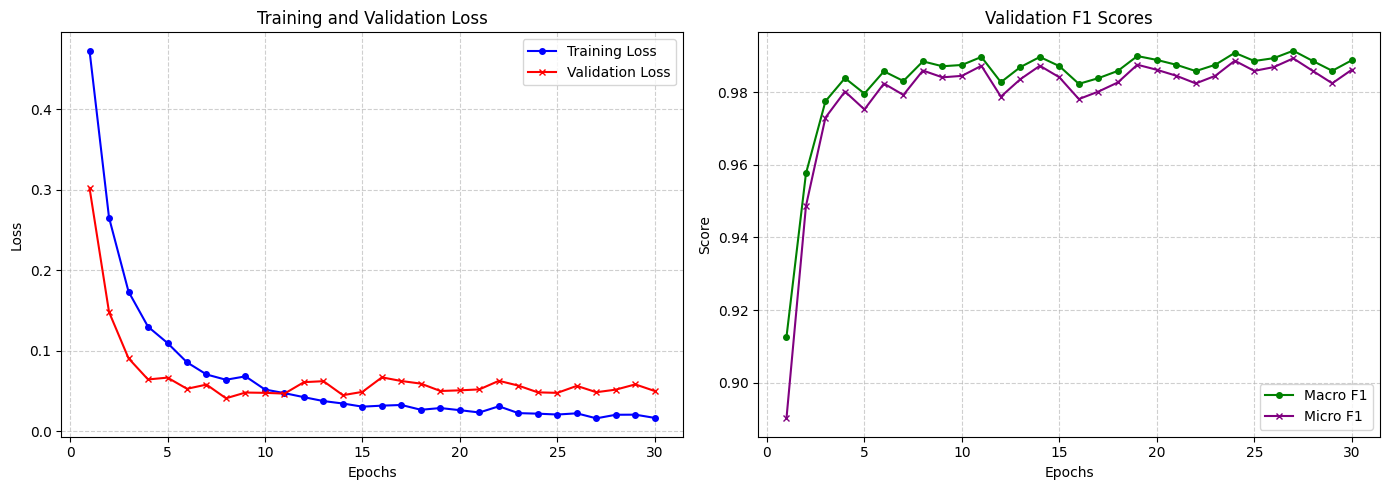

In [6]:
# ==============================
# IMPORTS
# ==============================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import f1_score, accuracy_score

# ==============================
# DEVICE CHECK
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("========================================")
print(f"USING DEVICE: {device}")
if device.type == "cuda":
    print(f"GPU NAME: {torch.cuda.get_device_name(0)}")
print("========================================\n")

# ==============================
# PATHS & SETTINGS
# ==============================
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_FEATURES = "/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

# ==============================
# IMAGE RESIZE WITH PADDING
# ==============================
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )

# ==============================
# LOAD CSV
# ==============================
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()

FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle"
]

feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8

# ==============================
# DATASET
# ==============================
class HybridDataset(Dataset):
    def __init__(self, df, image_root, mean, std):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # IMAGE
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # NUMERIC FEATURES
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # LABELS
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, feats, labels

train_dataset = HybridDataset(train_df, CROPPED_DIR, feat_mean, feat_std)
val_dataset   = HybridDataset(val_df, CROPPED_DIR, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ==============================
# MODEL: NAIVE EFFICIENTNET-B0
# ==============================
class BaselineEfficientNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 1. Pre-trained Visual Backbone
        self.cnn = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        
        # EfficientNet-B0 outputs 1280 dimensions. Project down to 128.
        self.cnn.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(1280, 128),
            nn.ReLU()
        )

        # NO NUMERICAL PROJECTION BRANCH

        # 2. Simple Classifier / Naive Fusion (128 visual + 6 raw math = 134)
        self.classifier = nn.Sequential(
            nn.Linear(134, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, image, features):
        x_img = self.cnn(image)
        
        # NAIVE FUSION
        x = torch.cat([x_img, features], dim=1)
        
        return self.classifier(x)

model = BaselineEfficientNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================
# EVALUATION
# ==============================
def evaluate(model, loader, criterion):
    model.eval()
    preds_all, labels_all = [], []
    val_loss = 0.0

    with torch.no_grad():
        for images, feats, labels in loader:
            images = images.to(device)
            feats = feats.to(device)
            labels = labels.to(device)

            outputs = model(images, feats)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            preds_all.append(preds)
            labels_all.append(labels.cpu().numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    
    avg_val_loss = val_loss / len(loader)

    return avg_val_loss, macro, micro, preds_all, labels_all

# ==============================
# TRACKERS FOR PLOTTING
# ==============================
history_train_loss = []
history_val_loss = []
history_val_macro = []
history_val_micro = []

# ==============================
# TRAINING LOOP
# ==============================
print("Starting Training with NAIVE EfficientNet-B0...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, feats, labels in train_loader:
        images = images.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss_epoch = running_loss / len(train_loader)
    val_loss_epoch, macro, micro, _, _ = evaluate(model, val_loader, criterion)

    history_train_loss.append(train_loss_epoch)
    history_val_loss.append(val_loss_epoch)
    history_val_macro.append(macro)
    history_val_micro.append(micro)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss_epoch:.4f} | "
        f"Val Loss: {val_loss_epoch:.4f} | "
        f"Val Macro F1: {macro:.4f}"
    )

# -------------------------
# FINAL METRICS & PLOTTING
# -------------------------
final_val_loss, final_macro, final_micro, preds, gts = evaluate(model, val_loader, criterion)

print("\n=== NAIVE EFFICIENTNET-B0 RESULTS ===")
print("-------------------------------------------------------")
labels_names = ["blur_present", "document_skew", "lighting_shadow"]
for i, lbl in enumerate(labels_names):
    f1 = f1_score(gts[:, i], preds[:, i])
    acc = accuracy_score(gts[:, i], preds[:, i])
    print(f"{lbl:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")
print("-------------------------------------------------------")
print(f"MACRO F1             | {final_macro:.4f}")
print(f"MICRO F1             | {final_micro:.4f}")

# ==============================
# PLOT THE LEARNING CURVES
# ==============================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_train_loss, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, history_val_loss, label='Validation Loss', color='red', marker='x', markersize=4)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_val_macro, label='Macro F1', color='green', marker='o', markersize=4)
plt.plot(epochs_range, history_val_micro, label='Micro F1', color='purple', marker='x', markersize=4)
plt.title('Validation F1 Scores')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 

USING DEVICE: cuda
GPU NAME: Tesla T4

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 106MB/s]


Starting Training with NAIVE EfficientNet-B0...

Epoch [1/30] | Train Loss: 0.6494 | Val Loss: 0.5046 | Val Macro F1: 0.8851
Epoch [2/30] | Train Loss: 0.4440 | Val Loss: 0.3363 | Val Macro F1: 0.9227
Epoch [3/30] | Train Loss: 0.3329 | Val Loss: 0.2469 | Val Macro F1: 0.9422
Epoch [4/30] | Train Loss: 0.2584 | Val Loss: 0.1757 | Val Macro F1: 0.9579
Epoch [5/30] | Train Loss: 0.2014 | Val Loss: 0.1280 | Val Macro F1: 0.9667
Epoch [6/30] | Train Loss: 0.1596 | Val Loss: 0.1024 | Val Macro F1: 0.9795
Epoch [7/30] | Train Loss: 0.1335 | Val Loss: 0.0807 | Val Macro F1: 0.9827
Epoch [8/30] | Train Loss: 0.1129 | Val Loss: 0.0651 | Val Macro F1: 0.9860
Epoch [9/30] | Train Loss: 0.0976 | Val Loss: 0.0840 | Val Macro F1: 0.9777
Epoch [10/30] | Train Loss: 0.0923 | Val Loss: 0.0578 | Val Macro F1: 0.9856
Epoch [11/30] | Train Loss: 0.0830 | Val Loss: 0.0665 | Val Macro F1: 0.9844
Epoch [12/30] | Train Loss: 0.0748 | Val Loss: 0.0548 | Val Macro F1: 0.9836
Epoch [13/30] | Train Loss: 0.0660 |

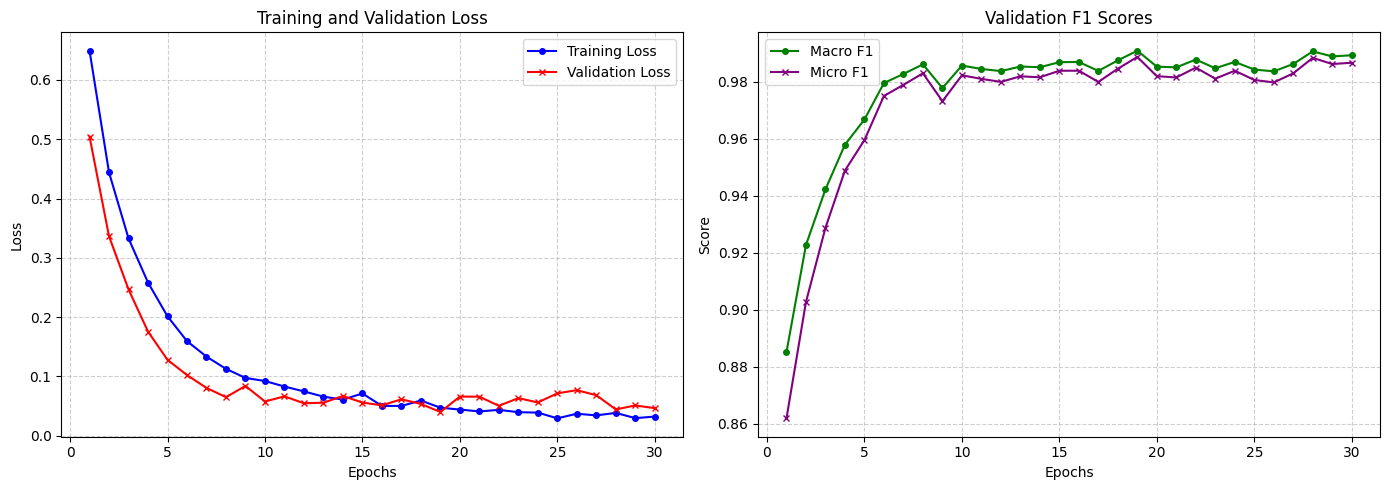

In [3]:
# ==============================
# IMPORTS
# ==============================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import f1_score, accuracy_score

# ==============================
# DEVICE CHECK
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("========================================")
print(f"USING DEVICE: {device}")
if device.type == "cuda":
    print(f"GPU NAME: {torch.cuda.get_device_name(0)}")
print("========================================\n")

# ==============================
# PATHS & SETTINGS
# ==============================
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"

TRAIN_FEATURES = "/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

# ==============================
# IMAGE RESIZE WITH PADDING
# ==============================
def resize_with_padding(image, target_size=224):
    h, w, _ = image.shape
    scale = target_size / max(h, w)

    new_h, new_w = int(h * scale), int(w * scale)
    image = cv2.resize(image, (new_w, new_h))

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    return cv2.copyMakeBorder(
        image,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0]
    )

# ==============================
# LOAD CSV
# ==============================
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()

FEATURE_COLS = [
    "var_laplacian",
    "tenengrad",
    "brenner",
    "fft_highfreq_ratio",
    "directional_grad_ratio",
    "skew_hough_angle"
]

feat_mean = train_df[FEATURE_COLS].mean()
feat_std  = train_df[FEATURE_COLS].std() + 1e-8

# ==============================
# DATASET
# ==============================
class HybridDataset(Dataset):
    def __init__(self, df, image_root, mean, std):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # IMAGE
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = resize_with_padding(image, IMG_SIZE)
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # NUMERIC FEATURES
        feats = row[FEATURE_COLS].values.astype(np.float32)
        feats = (feats - self.mean.values) / self.std.values
        feats = torch.tensor(feats, dtype=torch.float32)

        # LABELS
        blur_present = int(
            row["blur_motion"] == 1 or row["blur_outfocus"] == 1
        )

        labels = torch.tensor([
            blur_present,
            row["document_skew"],
            row["lighting_shadow"]
        ], dtype=torch.float32)

        return image, feats, labels

train_dataset = HybridDataset(train_df, CROPPED_DIR, feat_mean, feat_std)
val_dataset   = HybridDataset(val_df, CROPPED_DIR, feat_mean, feat_std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ==============================
# MODEL: EFFICIENTNET-B0
# ==============================
class EfficientNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 1. Pre-trained Visual Backbone
        self.cnn = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        
        # EfficientNet-B0 outputs 1280 dimensions. Project down to 128.
        self.cnn.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(1280, 128),
            nn.ReLU()
        )

          # 2. Numeric Branch (Your optimal setup)
        self.num_fc = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # 3. Fusion (Your optimal concatenation setup)
        self.fusion = nn.Sequential(
            nn.Linear(128 + 32, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 3)
        )

    def forward(self, image, features):
        x_img = self.cnn(image)
        x_num = self.num_fc(features)
        
        # Standard Concatenation Fusion
        x = torch.cat([x_img, x_num], dim=1)
        return self.fusion(x)

model = EfficientNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==============================
# EVALUATION
# ==============================
def evaluate(model, loader, criterion):
    model.eval()
    preds_all, labels_all = [], []
    val_loss = 0.0

    with torch.no_grad():
        for images, feats, labels in loader:
            images = images.to(device)
            feats = feats.to(device)
            labels = labels.to(device)

            outputs = model(images, feats)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            preds_all.append(preds)
            labels_all.append(labels.cpu().numpy())

    preds_all = np.vstack(preds_all)
    labels_all = np.vstack(labels_all)

    macro = f1_score(labels_all, preds_all, average="macro")
    micro = f1_score(labels_all, preds_all, average="micro")
    
    avg_val_loss = val_loss / len(loader)

    return avg_val_loss, macro, micro, preds_all, labels_all

# ==============================
# TRACKERS FOR PLOTTING
# ==============================
history_train_loss = []
history_val_loss = []
history_val_macro = []
history_val_micro = []

# ==============================
# TRAINING LOOP
# ==============================
print("Starting Training with NAIVE EfficientNet-B0...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, feats, labels in train_loader:
        images = images.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss_epoch = running_loss / len(train_loader)
    val_loss_epoch, macro, micro, _, _ = evaluate(model, val_loader, criterion)

    history_train_loss.append(train_loss_epoch)
    history_val_loss.append(val_loss_epoch)
    history_val_macro.append(macro)
    history_val_micro.append(micro)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss_epoch:.4f} | "
        f"Val Loss: {val_loss_epoch:.4f} | "
        f"Val Macro F1: {macro:.4f}"
    )

# -------------------------
# FINAL METRICS & PLOTTING
# -------------------------
final_val_loss, final_macro, final_micro, preds, gts = evaluate(model, val_loader, criterion)

print("\n=== EFFICIENTNET-B0 RESULTS ===")
print("-------------------------------------------------------")
labels_names = ["blur_present", "document_skew", "lighting_shadow"]
for i, lbl in enumerate(labels_names):
    f1 = f1_score(gts[:, i], preds[:, i])
    acc = accuracy_score(gts[:, i], preds[:, i])
    print(f"{lbl:20s} | F1: {f1:.4f} | Acc: {acc:.4f}")
print("-------------------------------------------------------")
print(f"MACRO F1             | {final_macro:.4f}")
print(f"MICRO F1             | {final_micro:.4f}")

# ==============================
# PLOT THE LEARNING CURVES
# ==============================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_train_loss, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, history_val_loss, label='Validation Loss', color='red', marker='x', markersize=4)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_val_macro, label='Macro F1', color='green', marker='o', markersize=4)
plt.plot(epochs_range, history_val_micro, label='Micro F1', color='purple', marker='x', markersize=4)
plt.title('Validation F1 Scores')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# MOBILENETV3

In [13]:
# ==============================
# IMPORTS
# ==============================
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import f1_score, accuracy_score

# ==============================
# PATHS & SETTINGS (Keep your existing paths)
# ==============================
CROPPED_DIR = "/kaggle/working/Final_Images_CROPPED"
TRAIN_FEATURES = "/kaggle/input/skew-dataset/train_blur_features_cropped_B3.csv"
VAL_FEATURES   = "/kaggle/input/skew-dataset/val_blur_features_cropped_B3.csv"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

# ==============================
# EARLY STOPPING CLASS
# ==============================
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path='visual_mobilenet_best.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# ==============================
# VISUAL-ONLY DATASET
# ==============================
class VisualDataset(Dataset):
    def __init__(self, df, image_root):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_root, row["image_path"])
        image = cv2.imread(img_path)
        if image is None: raise FileNotFoundError(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)) # Or your resize_with_padding
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        blur_present = int(row["blur_motion"] == 1 or row["blur_outfocus"] == 1)
        labels = torch.tensor([blur_present, row["document_skew"], row["lighting_shadow"]], dtype=torch.float32)

        return image, labels

# Load Data
train_df = pd.read_csv(TRAIN_FEATURES).dropna()
val_df   = pd.read_csv(VAL_FEATURES).dropna()
train_loader = DataLoader(VisualDataset(train_df, CROPPED_DIR), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(VisualDataset(val_df, CROPPED_DIR), batch_size=BATCH_SIZE, shuffle=False)

# ==============================
# MODEL: VISUAL MOBILENETV3-SMALL
# ==============================
class VisualMobileNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Pre-trained backbone
        self.model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        
        # Replace the classifier to output 3 classes directly (Visual Only)
        in_features = self.model.classifier[3].in_features
        self.model.classifier[3] = nn.Linear(in_features, 3)

    def forward(self, x):
        return self.model(x)

model = VisualMobileNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
early_stopping = EarlyStopping(patience=5, verbose=True, path='visual_mobilenet_best.pt')

# ==============================
# EVALUATION FUNCTION
# ==============================
def evaluate(model, loader, criterion):
    model.eval()
    preds_all, labels_all, val_loss = [], [], 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            preds_all.append(preds); labels_all.append(labels.cpu().numpy())
    
    preds_all, labels_all = np.vstack(preds_all), np.vstack(labels_all)
    return val_loss/len(loader), f1_score(labels_all, preds_all, average="macro"), f1_score(labels_all, preds_all, average="micro"), preds_all, labels_all

# ==============================
# TRAINING LOOP
# ==============================
history = {'t_loss': [], 'v_loss': [], 'macro': [], 'micro': []}
print("Starting Training: Visual-Only MobileNetV3 Baseline...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item()

    v_loss, macro, micro, _, _ = evaluate(model, val_loader, criterion)
    history['t_loss'].append(running_loss/len(train_loader))
    history['v_loss'].append(v_loss); history['macro'].append(macro); history['micro'].append(micro)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {history['t_loss'][-1]:.4f} | Val Loss: {v_loss:.4f} | Macro F1: {macro:.4f}")
    
    early_stopping(v_loss, model)
    if early_stopping.early_stop: break

# ==============================
# FINAL RESULTS & EFFICIENCY
# ==============================
model.load_state_dict(torch.load('visual_mobilenet_best.pt'))
_, final_macro, _, preds, gts = evaluate(model, val_loader, criterion)

print("\n=== VISUAL MOBILENET-V3 BASELINE RESULTS ===")
for i, lbl in enumerate(["blur_present", "document_skew", "lighting_shadow"]):
    print(f"{lbl:20s} | F1: {f1_score(gts[:, i], preds[:, i]):.4f} | Acc: {accuracy_score(gts[:, i], preds[:, i]):.4f}")

# Plotting logic is identical to your previous code...
# Efficiency Metrics:
print("\n=== COMPUTATIONAL EFFICIENCY ===")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model Size: {os.path.getsize('visual_mobilenet_best.pt')/(1024*1024):.2f} MB")

# Latency Check
model.eval()
dummy = torch.randn(1, 3, 224, 224).to(device)
start = time.time()
for _ in range(100): _ = model(dummy)
print(f"Latency (1 image): {(time.time()-start)/100:.5f}s")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 110MB/s]


Starting Training: Visual-Only MobileNetV3 Baseline...

Epoch [1/30] | Train Loss: 0.4029 | Val Loss: 0.4290 | Macro F1: 0.8490
Validation loss decreased (inf --> 0.429010). Saving model...
Epoch [2/30] | Train Loss: 0.2202 | Val Loss: 0.1709 | Macro F1: 0.9500
Validation loss decreased (0.429010 --> 0.170871). Saving model...
Epoch [3/30] | Train Loss: 0.1568 | Val Loss: 0.1349 | Macro F1: 0.9584
Validation loss decreased (0.170871 --> 0.134867). Saving model...
Epoch [4/30] | Train Loss: 0.1283 | Val Loss: 0.1275 | Macro F1: 0.9629
Validation loss decreased (0.134867 --> 0.127516). Saving model...
Epoch [5/30] | Train Loss: 0.0993 | Val Loss: 0.1054 | Macro F1: 0.9693
Validation loss decreased (0.127516 --> 0.105448). Saving model...
Epoch [6/30] | Train Loss: 0.0895 | Val Loss: 0.0945 | Macro F1: 0.9739
Validation loss decreased (0.105448 --> 0.094523). Saving model...
Epoch [7/30] | Train Loss: 0.0819 | Val Loss: 0.0906 | Macro F1: 0.9725
Validation loss decreased (0.094523 --> 0.0

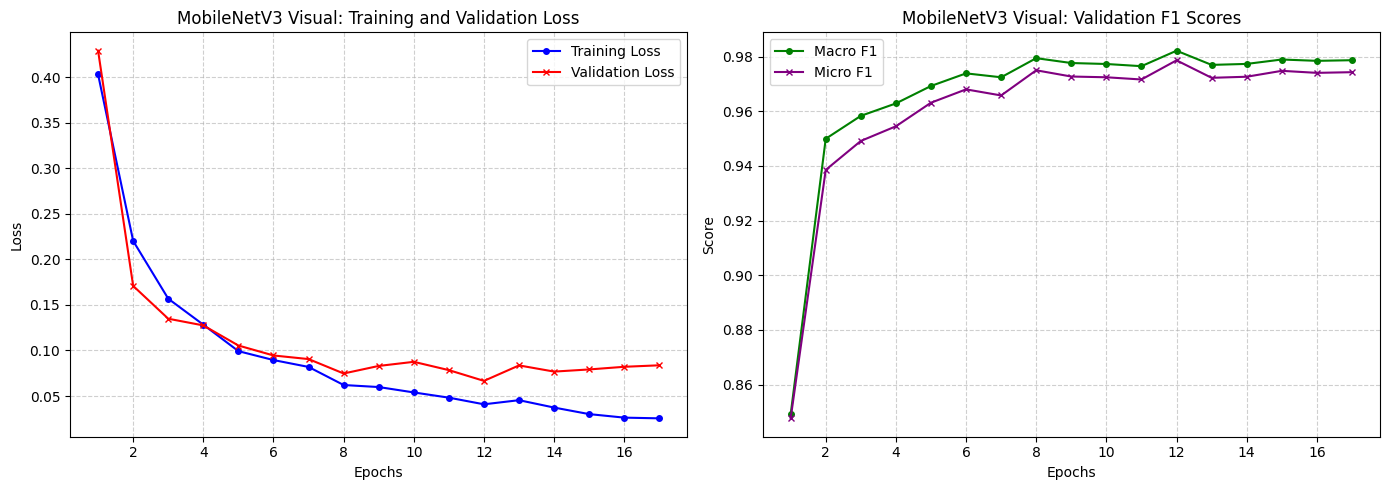

In [14]:
# ==============================
# PLOT THE LEARNING CURVES
# ==============================
# Adjust epochs range based on how many epochs actually ran before Early Stopping
actual_epochs = len(history['t_loss'])
epochs_range = range(1, actual_epochs + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Training vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['t_loss'], label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, history['v_loss'], label='Validation Loss', color='red', marker='x', markersize=4)
plt.title('MobileNetV3 Visual: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Validation F1 Scores (Macro & Micro)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['macro'], label='Macro F1', color='green', marker='o', markersize=4)
plt.plot(epochs_range, history['micro'], label='Micro F1', color='purple', marker='x', markersize=4)
plt.title('MobileNetV3 Visual: Validation F1 Scores')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('mobilenet_visual_baseline_graphs.png') # Saves the figure to your Kaggle working dir
plt.show()